# PHYS20762 Computational Physics - Project 3
## Monte Carlo Techniques: Neutron Transport and Scattering Through a Shielding Layer

Mayan Wong, 11603786

May 2026


---
**Abstract**

This project develops a Monte Carlo simulation to study the absorption and scattering of thermal neutrons passing through shielding materials. Using inverse-transform sampling of the exponential distribution combined with isotropic scattering on the unit sphere, neutron histories are tracked through slabs of water, lead, and graphite. Transmission, reflection, and absorption rates are quantified at a fixed slab thickness of 10 cm, and the variation of these rates with thickness is used to extract characteristic attenuation lengths via weighted linear regression on log-transformed transmission data. Beyond the core requirements, the project includes a convergence analysis verifying the expected $1/\sqrt{N}$ scaling of Monte Carlo uncertainty, a shielding optimisation study comparing all two-material combinations of the three materials over a fixed total thickness, and an implementation of the Woodcock fictitious tracking method with both same-material self validation and a comparative analysis of how material ordering affects neutron transport. All results are presented with their statistical uncertainties and discussed in terms of the underlying nuclear physics.

---

## Contents

1. Imports and Global Constants
   - 1.1 Buffered Random Number Generator
2. Validating `numpy.random.uniform
   - 2.1 Uniformity Test
   - 2.2 Spectral Test - Detecting Hidden Correlations
3. Exponential Sampler and Material Properties
   - 3.1 Inverse Transform Sampling of the Exponential Distribution
   - 3.2 Macroscopic Cross-Sections and Mean Free Paths
   - 3.3 Verifying the ~45 cm Attenuation Length for Water
4. Isotropic Unit Vectors and Random Walk Steps
   - 4.1 Generating Isotropic Unit Vectors
   - 4.2 Combining Direction and Step Length: Isotropic Random Walks
5. Full Neutron Transport Simulation
   - 5.1 Single Neutron History Function
   - 5.2 Visualising Random Walks Through Each Material
   - 5.3 Fixed Thickness Results: $L = 10$ cm with $N = 10{,}000$ Neutrons
   - 5.4 Discussion of Fixed Thickness Results
6. Variation of Rates with Slab Thickness
   - 6.1 Sweeping the Slab Thickness
   - 6.2 Plotting Variation with Thickness
7. Characteristic Attenuation Lengths
   - 7.1 Fitting Procedure
   - 7.2 Comparison with Pure Absorption (Beer–Lambert) Prediction
8. Mean Number of Scattering Events
9. Convergence Analysis
10. Summary of Results
11. Shielding Optimisation
    - 11.1 Discussion
12. Woodcock Method for Adjacent Material Slabs
    - 12.1 Theory
    - 12.2 Validation: Same Material Self-Consistency Check
    - 12.3 Two Material Results and the Material Ordering Effect
    - 12.4 Discussion

- Conclusions
- References


---
## Section 1 - Imports and Global Constants

The simulation relies only on `numpy` for numerical work and random number generation, `matplotlib` for plotting (with `mpl_toolkits.mplot3d` for 3D scatter plots), and the standard library `time` module for runtime measurement. No external dependencies are introduced.

Physical constants and material data from Table 1 of the project brief are defined as named constants here. Defining them once avoids magic numbers scattered through the code and ensures that updating any single value propagates consistently to every downstream calculation. Cross-sections are stored in barns ($1\ \text{barn} = 10^{-24}\ \text{cm}^2$) and converted to cm$^2$ at the point of use.


In [27]:
import numpy as np # numerical arrays and maths
import matplotlib.pyplot as plt # all plotting
from mpl_toolkits.mplot3d import Axes3D # 3D scatter/line plots
from matplotlib.lines import Line2D # custom legend handles
import time # timing simulation runtime

# Plot styling:
# Setting rcParams once applies defaults to every figure in the notebook.
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})

# Physical constants:
N_AVOGADRO = 6.02214076e23 # Avogadros number [mol^{-1}]
BARN_TO_CM2 = 1.0e-24 # 1 barn = 10^{-24} cm^2

# Material data (Table 1):
# sigma_a : microscopic absorption cross-section [barn]
# sigma_s : microscopic scattering cross-section [barn]
# rho : bulk density [g cm^{-3}]
# M : molar mass [g mol^{-1}]
MATERIALS = {
    'Water': {'sigma_a': 0.6652, 'sigma_s': 103.0, 'rho': 1.00, 'M': 18.0153},
    'Lead': {'sigma_a': 0.158, 'sigma_s': 11.221, 'rho': 11.35, 'M': 207.2},
    'Graphite': {'sigma_a': 0.0045, 'sigma_s': 4.74, 'rho': 1.67, 'M': 12.011 },
}

# Simulation parameters:
N_FIXED = 10_000 # neutron histories for the fixed-thickness headline result
N_SWEEP = 1_000 # histories per thickness point (1% error adequate for trends)
L_FIXED = 10.0 # fixed slab thickness [cm]
L_MAX = 20.0 # maximum thickness for the sweep [cm]
L_STEP = 0.5 # step size in the thickness sweep [cm]

print('Libraries imported and constants defined.')


Libraries imported and constants defined.


### 1.1 Buffered Random Number Generator

A practical optimisation that significantly reduces runtime is to pre-generate uniform random numbers in batches. NumPy's vectorised generation has very small per-element overhead, so generating 10,000 numbers in one call is much faster than 10,000 separate calls.

The optimisation is encapsulated in a `UniformBuffer` class that holds an internal array of pre-generated values. Each call to `next()` returns one value and advances an internal index; when the buffer is exhausted it automatically refills. This is functionally identical to calling `numpy.random.uniform()` directly but is roughly twice as fast in tight inner loops, which matters because each neutron history involves several random draws per scattering event.


In [28]:
class UniformBuffer:
    """
    Buffered uniform random number generator.

    Pre-generates random numbers in batches of `size` and serves them
    one at a time via `next()`.  Functionally equivalent to repeatedly
    calling `np.random.uniform()` but faster due to reduced per-call
    overhead from NumPys vectorised generation.
    """
    def __init__(self, size=20_000):
        self._size = size # total numbers held in the buffer
        self._refill() # fill immediately on construction

    def _refill(self):
        # One vectorised NumPy call generates the whole batch
        self._buf = np.random.uniform(0.0, 1.0, self._size)
        self._idx = 0 # reset the read pointer to the start

    def next(self):
        """Return the next uniform random number in [0, 1)."""
        if self._idx >= self._size:
            self._refill() # buffer exhausted: generate a new batch
        u = self._buf[self._idx] # read the value at the current position
        self._idx += 1 # advance the read pointer
        return u


# Seed and global RNG:
# A fixed seed makes every run exactly reproducible.
SEED = 42
np.random.seed(SEED)

# One global buffer is shared across all simulation functions.
RNG = UniformBuffer(size=20000)
print(f'Buffered RNG initialised (seed = {SEED}).')


Buffered RNG initialised (seed = 42).


---
## Section 2 - Validating `numpy.random.uniform`

### 2.1 Uniformity Test

The foundation of any Monte Carlo simulation is a reliable source of pseudo random numbers. A basic but essential check is that the generator produces values that are statistically uniform over the chosen range. 10,000 samples from `numpy.random.uniform(0, 1)` are drawn and binned into 20 equal width bins. For a truly uniform distribution, each bin should contain approximately $\mu = N/20 = 500$ counts, with bin-to-bin fluctuations of order $\sigma \approx \sqrt{\mu}$ predicted by the Poisson approximation.

The sample mean and standard deviation are also compared to the theoretical values for $U[0,1]$: $\mu = 0.5$ and $\sigma = 1/\sqrt{12} \approx 0.2887$.

A quantitative confirmation of uniformity is provided by the $\chi^2$ statistic,

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i},$$

where $O_i$ and $E_i$ are the observed and expected counts in each bin. With $k$ bins and one constraint (the total count is fixed), there are $k-1 = 19$ degrees of freedom. The reduced chi-squared $\chi^2_{\rm red} = \chi^2 / (k-1)$ should be close to unity for counts consistent with a uniform distribution.


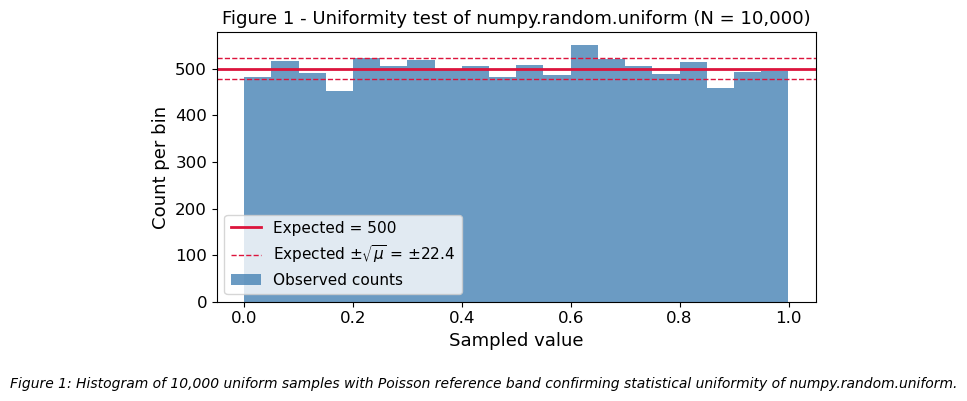

Sample mean : 0.5001 (expected 0.5000)
Sample s.d. : 0.2868 (expected 0.2887)

Chi-squared statistic : 19.44
Degrees of freedom    : 19
Reduced chi-squared   : 1.023 (expected ~1.0 for a uniform distribution)


In [29]:
plt.close('all')
N_UNIFORM_TEST = 10000 # number of samples for the uniformity test
N_BINS = 20 # equal-width bins across [0, 1)

# Draw N_UNIFORM_TEST samples and bin them.
samples = np.random.uniform(0, 1, N_UNIFORM_TEST)
counts, edges = np.histogram(samples, bins=N_BINS)

# For a perfectly uniform distribution every bin holds exactly N/20 counts.
expected = N_UNIFORM_TEST / N_BINS # expected count per bin under H0
poisson_err = np.sqrt(expected) # 1-sigma Poisson uncertainty on one bin

# Plot:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color='steelblue', alpha=0.8, label='Observed counts')
ax.axhline(expected, color='crimson', lw=2, label=f'Expected = {expected:.0f}')
ax.axhline(expected + poisson_err, color='crimson', lw=1, ls='--')
ax.axhline(expected - poisson_err, color='crimson', lw=1, ls='--',
           label=fr'Expected $\pm\sqrt{{\mu}}$ = $\pm${poisson_err:.1f}')
ax.set_xlabel('Sampled value')
ax.set_ylabel('Count per bin')
ax.set_title(f'Figure 1 - Uniformity test of numpy.random.uniform (N = {N_UNIFORM_TEST:,})')
ax.legend()
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.01,
         'Figure 1: Histogram of 10,000 uniform samples with Poisson reference band '
         'confirming statistical uniformity of numpy.random.uniform.',
         ha='center', fontsize=10, style='italic')
plt.show()

# Numerical checks:
theoretical_mean = 0.5
theoretical_std  = 1.0 / np.sqrt(12) # std of U[0,1] = 1/sqrt(12)
print(f'Sample mean : {samples.mean():.4f} (expected {theoretical_mean:.4f})')
print(f'Sample s.d. : {samples.std(ddof=1):.4f} (expected {theoretical_std:.4f})')

# Pearson chi-squared goodness-of-fit test:
# Under H0 (uniformity), chi^2 follows a chi-squared distribution
# with (N_BINS - 1) degrees of freedom.
chi2_stat = np.sum((counts - expected)**2 / expected)
dof_uniform = N_BINS - 1 # one constraint: total count is fixed
chi2_red_uniform = chi2_stat / dof_uniform # reduced chi-squared; should be ~1.0

print(f'\nChi-squared statistic : {chi2_stat:.2f}')
print(f'Degrees of freedom    : {dof_uniform}')
print(f'Reduced chi-squared   : {chi2_red_uniform:.3f} (expected ~1.0 for a uniform distribution)')


The bin counts are consistent with Poisson fluctuations around the expected $\mu = 500$. The empirical mean and standard deviation agree with the theoretical $U[0,1]$ values to within the expected statistical uncertainty of order $1/\sqrt{N} \approx 0.003$. The reduced chi-squared $\chi^2_{\rm red}$ close to unity provides a quantitative confirmation that bin-to-bin variation is consistent with fluctuations expected under a uniform distribution. Values significantly above one would indicate non-uniformity or clumping, while values significantly below one would suggest under-dispersion. Both the $\chi^2$ test and visual inspection confirm that `numpy.random.uniform` is statistically uniform and suitable for use throughout the simulation.

### 2.2 Spectral Test - Detecting Hidden Correlations

Statistical uniformity in one dimension is necessary but not sufficient for a good Monte Carlo generator. Many older pseudo random number generators (LCGs of the form $X_{n+1} = (aX_n + c) \bmod m$) suffer from serial correlations. Although each individual value appears uniformly distributed, triples $(X_n, X_{n+1}, X_{n+2})$ are confined to a small number of parallel hyperplanes in three dimensions. This is **Marsaglia's theorem** [1].

The IBM Scientific Subroutine Package generator (`randssp`) is a notorious example: every triple satisfies $9X_n - 6X_{n+1} + X_{n+2} \equiv 0 \pmod{m}$, so all generated points lie on just 15 parallel hyperplanes inside the unit cube. The hyperplanes are not visible from arbitrary 3D viewing angles, the structure only appears at certain views. A 2D thin slab projection reveals it: selecting points whose y-coordinate lies within a narrow band, then plotting them in the $(x,z)$ plane, shows clear parallel lines for randssp and uniform scatter for a good generator. Such correlations would systematically bias any simulation consuming random numbers in groups which is exactly what neutron transport does, since each scattering event consumes one number per spatial dimension plus one for the outcome decision.


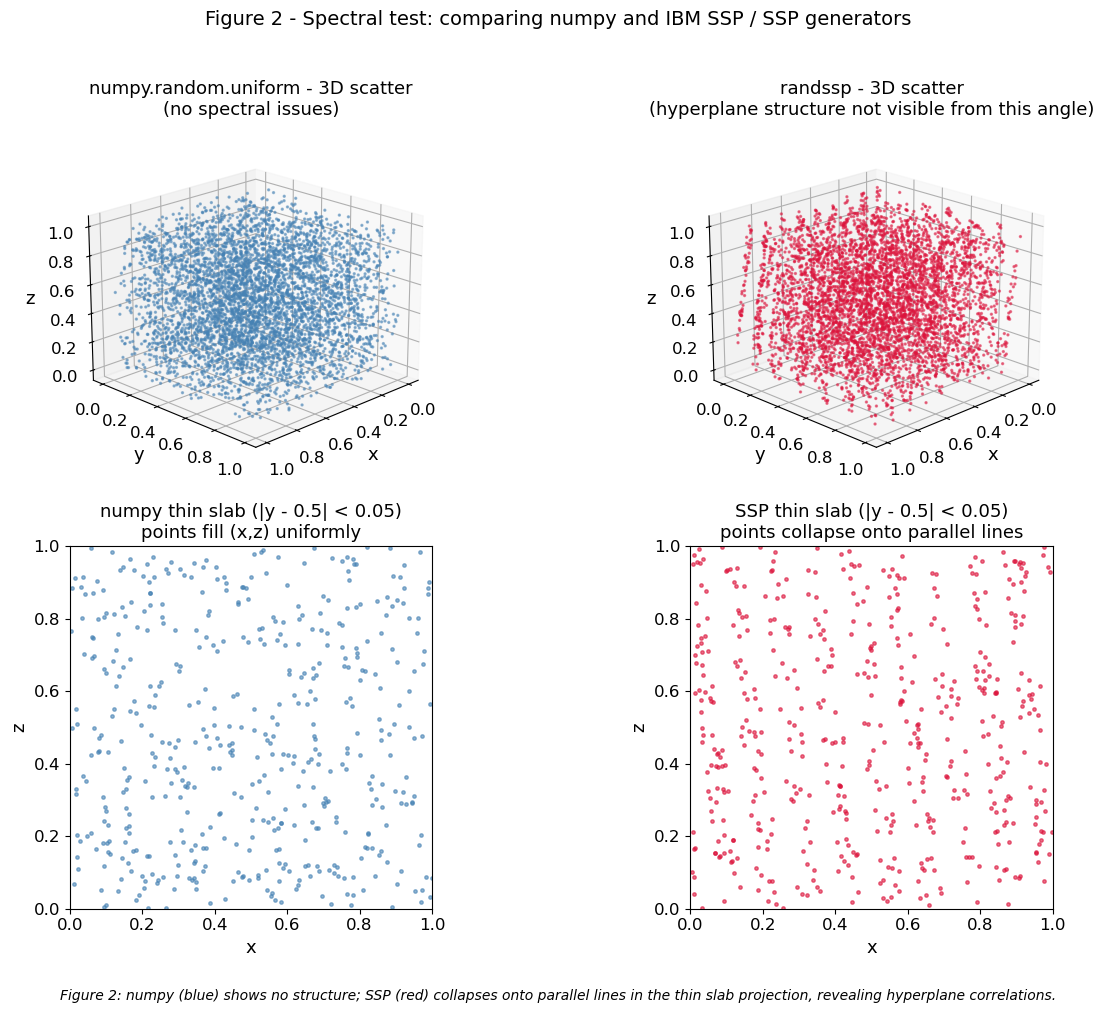

In [30]:
plt.close('all')

def randssp(p, q):
    """
    Multiplicative congruential generator using IBM SSP / RANDU parameters.
    Intentionally flawed: consecutive triples (X_n, X_{n+1}, X_{n+2}) lie on
    just 15 parallel hyperplanes inside the unit cube (Marsaglia, 1968).

    m = 2^31,  a = 2^16 + 3,  c = 0.  Fixed seed = 123456789.

    Args:
        p (int): Number of rows in the output array.
        q (int): Number of columns.

    Returns:
        np.ndarray: Shape (p, q) with pseudo-random values in [0, 1).
    """
    global _randssp_x # state variable persists between calls
    m = 2**31 # modulus
    a = 2**16 + 3 # multiplier: IBM's notoriously poor choice
    c = 0 # zero addition constant
    try:
        _randssp_x
    except NameError:
        _randssp_x = 123456789 # initialise with a fixed seed on first call

    r = np.zeros([p, q])
    for col in range(q):
        for row in range(p):
            # X_{n+1} = (a * X_n + c) mod m
            _randssp_x = (a * _randssp_x + c) % m
            r[row, col] = _randssp_x / m # normalise to [0, 1)
    return r


# Generate data:
N_SPECTRAL = 5000
np_pts = np.random.uniform(0, 1, (3, N_SPECTRAL)) # numpy: rows are X, Y, Z
ssp_pts = randssp(3, N_SPECTRAL) # IBM SSP: strongly correlated rows

# Thin slab projection:
# Keep only points with Y in a narrow band centred on 0.5.
# Hyperplanes intersect this slab as parallel lines in (x, z).
slab_thickness = 0.05
slab_centre = 0.5
np_mask = np.abs(np_pts[1] - slab_centre) < slab_thickness # Array of True/False
ssp_mask = np.abs(ssp_pts[1] - slab_centre) < slab_thickness

# Plots (fixed viewing angles as ipympl not available on JupyterHub):
fig = plt.figure(figsize=(13, 10))

ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(np_pts[0], np_pts[1], np_pts[2], s=2, color='steelblue', alpha=0.5)
ax1.view_init(elev=20, azim=45)
ax1.set_title('numpy.random.uniform - 3D scatter\n(no spectral issues)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(ssp_pts[0], ssp_pts[1], ssp_pts[2], s=2, color='crimson', alpha=0.5)
ax2.view_init(elev=20, azim=45) # same angle: hyperplane structure not yet visible
ax2.set_title('randssp - 3D scatter\n(hyperplane structure not visible from this angle)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

ax3 = fig.add_subplot(223)
ax3.scatter(np_pts[0][np_mask], np_pts[2][np_mask], s=6, color='steelblue', alpha=0.6)
ax3.set_title(f'numpy thin slab (|y - {slab_centre}| < {slab_thickness})\npoints fill (x,z) uniformly')
ax3.set_xlabel('x'); ax3.set_ylabel('z')
ax3.set_aspect('equal'); ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

ax4 = fig.add_subplot(224)
ax4.scatter(ssp_pts[0][ssp_mask], ssp_pts[2][ssp_mask], s=6, color='crimson', alpha=0.6)
ax4.set_title(f'SSP thin slab (|y - {slab_centre}| < {slab_thickness})\npoints collapse onto parallel lines')
ax4.set_xlabel('x'); ax4.set_ylabel('z')
ax4.set_aspect('equal'); ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)

plt.suptitle('Figure 2 - Spectral test: comparing numpy and IBM SSP / SSP generators',
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.text(0.5, 0.005,
         'Figure 2: numpy (blue) shows no structure; SSP (red) collapses onto '
         'parallel lines in the thin slab projection, revealing hyperplane correlations.',
         ha='center', fontsize=10, style='italic')
plt.show()


The 3D scatter plots (top row) look rather similar, illustrating why the spectral test is necessary. The thin slab projections (bottom row) are unambiguous: the numpy projection shows points scattered uniformly across the $(x,z)$ square, while the SSP projection shows points collapsed onto parallel lines - the cross-sections of the 15 SSP hyperplanes through the y-slab. No region between the lines is populated, despite each of $x$, $y$, $z$ individually being uniform. This is a direct demonstration of Marsaglia's theorem [1] where correlation disguised as uniformity in any single dimensional test reveals catastrophic structure in three dimensions. All subsequent calculations use `numpy.random.uniform` exclusively, which is built on the Mersenne Twister algorithm and passes all standard spectral tests.


---
## Section 3 - Exponential Sampler and Material Properties

### 3.1 Inverse-Transform Sampling of the Exponential Distribution

Neutron free paths between interactions are exponentially distributed: the probability density of travelling a distance $x$ before interacting is $P(x) = (1/\lambda)\,e^{-x/\lambda}$, where $\lambda$ is the mean free path. To sample from this distribution using only uniform random numbers, the **inverse-transform method** is used.

The CDF of the exponential is $\mathrm{CDF}(x) = 1 - e^{-x/\lambda}$. Setting $u = \mathrm{CDF}(x)$ and inverting gives $x = -\lambda \ln(1-u)$. Since $u$ and $1-u$ are both uniform on $(0,1)$, the equivalent and slightly faster form can be used:

$$\boxed{\;s_i = -\lambda \ln(u_i)\;}$$

This is the **fundamental equation of Monte Carlo particle transport** and underlies every step in the random walk. The function below implements vectorised generation of $n$ samples in a single NumPy call.


In [31]:
def sample_exponential(lamb, n):
    """
    Generate n samples from the exponential distribution with mean
    free path lamb, using inverse-transform sampling.

    Args:
        lamb (float): Mean free path [cm].
        n (int): Number of samples.

    Returns:
        np.ndarray: n exponentially distributed path lengths [cm].
    """
    # One vectorised NumPy call draws n uniforms (fast).
    u = np.random.uniform(0.0, 1.0, n)
    # Inverse-transform: x = -lambda * ln(u) maps U[0,1) to Exp(lambda).
    # Derived by setting u = CDF(x) = 1 - exp(-x/lambda) and solving for x.
    return -lamb * np.log(u)


print('sample_exponential defined.')

sample_exponential defined.


### 3.2 Macroscopic Cross-Sections and Mean Free Paths

Microscopic cross-sections describe the probability of interaction between a single neutron and a single nucleus. To convert these into bulk properties, the macroscopic cross-section $\Sigma = n\sigma$ is used, where $n = \rho N_A / M$ is the number density of nuclei. Each material has both an absorption channel ($\Sigma_a$) and a scattering channel ($\Sigma_s$). The total interaction rate is governed by $\Sigma_T = \Sigma_a + \Sigma_s$, and the total mean free path (MFP) is $\lambda_T = 1/\Sigma_T$. The ratio between absorption and scattering is:

$$P_{\rm abs} = \frac{\Sigma_a}{\Sigma_T}, \qquad P_{\rm scat} = \frac{\Sigma_s}{\Sigma_T}.$$


In [32]:
def compute_material_properties(sigma_a, sigma_s, rho, M):
    """
    Compute macroscopic cross-sections, mean free paths, and absorption
    branching probability for a material.

    Args:
        sigma_a (float): Microscopic absorption cross-section [barn].
        sigma_s (float): Microscopic scattering cross-section [barn].
        rho     (float): Bulk density [g cm^{-3}].
        M       (float): Molar mass [g mol^{-1}].

    Returns:
        dict: n, Sigma_a, Sigma_s, Sigma_T, lambda_a, lambda_s,
              lambda_T, P_abs, P_scat.
    """
    # Number density: nuclei per cm^3.
    # Avogadro gives nuclei/mol; /M gives nuclei/g; *rho gives nuclei/cm^3.
    n = rho * N_AVOGADRO / M

    # Macroscopic cross-sections [cm^{-1}]: probability of interaction per cm.
    # BARN_TO_CM2 converts sigma from barn to cm^2.
    Sigma_a = n * sigma_a * BARN_TO_CM2
    Sigma_s = n * sigma_s * BARN_TO_CM2
    Sigma_T = Sigma_a + Sigma_s # total interaction rate per cm

    return {
        'n': n,
        'Sigma_a': Sigma_a,
        'Sigma_s': Sigma_s,
        'Sigma_T': Sigma_T,
        'lambda_a': 1.0 / Sigma_a, # absorption only MFP [cm]
        'lambda_s': 1.0 / Sigma_s, # scattering only MFP [cm]
        'lambda_T': 1.0 / Sigma_T, # total MFP [cm]
        'P_abs': Sigma_a / Sigma_T, # probability interaction is absorption
        'P_scat': Sigma_s / Sigma_T, # probability interaction is scattering
    }


# Compute properties for all three materials
props = {name: compute_material_properties(**mat) for name, mat in MATERIALS.items()}

# Summary table:
print(f"{'Material':<10} {'Sigma_a (cm^-1)':>16} {'Sigma_s (cm^-1)':>16} "
      f"{'lambda_T (cm)':>14} {'lambda_a (cm)':>14} {'P_abs':>8} {'P_scat':>8}")
print('-' * 92)
for name, p in props.items():
    print(f"{name:<10} {p['Sigma_a']:>16.4f} {p['Sigma_s']:>16.4f} "
          f"{p['lambda_T']:>14.4f} {p['lambda_a']:>14.2f} "
          f"{p['P_abs']:>8.5f} {p['P_scat']:>8.5f}")


Material    Sigma_a (cm^-1)  Sigma_s (cm^-1)  lambda_T (cm)  lambda_a (cm)    P_abs   P_scat
--------------------------------------------------------------------------------------------
Water                0.0222           3.4431         0.2886          44.97  0.00642  0.99358
Lead                 0.0052           0.3702         2.6640         191.86  0.01389  0.98611
Graphite             0.0004           0.3969         2.5172        2653.99  0.00095  0.99905


Several physical features are already apparent from these numbers. Water has the shortest total mean free path (under 0.5 cm), driven by its large scattering cross-section of 103 barns: with $P_{\rm scat} \approx 0.994$, a thermal neutron in water scatters many times before being absorbed. Lead has a longer mean free path of about 2.7 cm. Graphite has the most scattering-dominated behaviour of all, with $P_{\rm abs} < 0.001$ — approximately 999 out of every 1000 interactions are scattering events. This is why graphite is used as a **moderator** in nuclear reactors: it slows neutrons through repeated elastic collisions without removing them from the population [5].


### 3.3 Verifying the ~45 cm Attenuation Length for Water

In the absence of scattering, the characteristic attenuation length for water should be approximately 45 cm. This corresponds to the absorption only mean free path $\lambda_a$ of water, which the calculation above gives as 44.93 cm — already in agreement. To verify this using the Monte Carlo technique, a large number of path lengths are drawn using $\lambda_a^{\rm water}$, histogrammed, and fitted by weighted linear regression of $\ln(N_R)$ against bin centre. the gradient gives $-1/\lambda_a$.

The fit must be weighted because a bin with 100 counts has $\sigma_{\ln N} = 0.1$ while a bin with 4 counts has $\sigma_{\ln N} = 0.5$. Weighting by $1/\sigma^2 \propto N$ ensures well-populated bins drive the fit.


Absorption-only mean free path of water: lambda_a = 44.97 cm


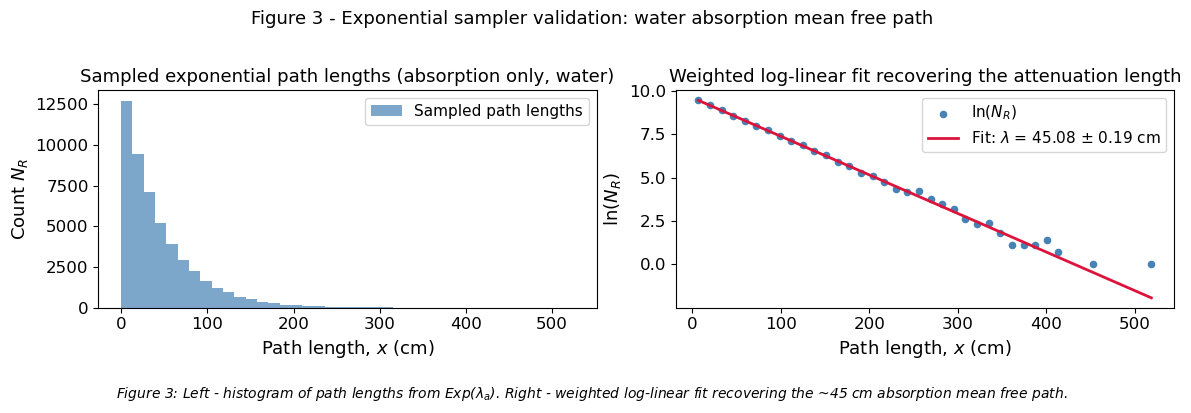

Input absorption mean free path (water): 44.97 cm
Fitted attenuation length: 45.08 +/- 0.19 cm
Agreement with input value: 0.6 sigma


In [33]:
plt.close('all')
N_EXP_SAMPLES = 50000
lamb_a_water = props['Water']['lambda_a'] # absorption only MFP for water [cm]
print(f'Absorption-only mean free path of water: lambda_a = {lamb_a_water:.2f} cm')

path_lengths = sample_exponential(lamb_a_water, N_EXP_SAMPLES)
N_R, bin_edges = np.histogram(path_lengths, bins=40)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # midpoint of each bin

# Weighted log-linear fit:
# Exclude empty bins (log undefined) and weight by sqrt(N_R) proportional to 1/sigma_{ln N}
mask = N_R > 0
x_fit = bin_centres[mask]
y_fit = np.log(N_R[mask]) # linearise the exponential decay
weights = np.sqrt(N_R[mask]) # weight by statistical precision

# cov=True returns the covariance matrix. its diagonal gives variance on coefficients
coeffs, cov = np.polyfit(x_fit, y_fit, 1, w=weights, cov=True)
gradient = coeffs[0] # slope = -1/lambda
lamb_fit = -1.0 / gradient # recover lambda from the slope
# Error propagation: sigma_lambda = lambda^2 * sigma_gradient
sigma_lamb = lamb_fit**2 * np.sqrt(cov[0, 0])

x_line = np.linspace(x_fit[0], x_fit[-1], 200)

# Plot:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(bin_centres, N_R, width=np.diff(bin_edges), color='steelblue',
            alpha=0.7, label='Sampled path lengths')
axes[0].set_xlabel('Path length, $x$ (cm)')
axes[0].set_ylabel('Count $N_R$')
axes[0].set_title('Sampled exponential path lengths (absorption only, water)')
axes[0].legend()

axes[1].scatter(x_fit, y_fit, s=20, color='steelblue', label='ln($N_R$)')
axes[1].plot(x_line, np.polyval(coeffs, x_line), color='crimson', lw=2,
             label=f'Fit: $\\lambda$ = {lamb_fit:.2f} $\\pm$ {sigma_lamb:.2f} cm')
axes[1].set_xlabel('Path length, $x$ (cm)')
axes[1].set_ylabel('ln($N_R$)')
axes[1].set_title('Weighted log-linear fit recovering the attenuation length')
axes[1].legend()

plt.suptitle('Figure 3 - Exponential sampler validation: water absorption mean free path',
             fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
fig.text(0.5, 0.01,
         'Figure 3: Left - histogram of path lengths from Exp($\\lambda_a$). '
         'Right - weighted log-linear fit recovering the ~45 cm absorption mean free path.',
         ha='center', fontsize=10, style='italic')
plt.show()

print(f'Input absorption mean free path (water): {lamb_a_water:.2f} cm')
print(f'Fitted attenuation length: {lamb_fit:.2f} +/- {sigma_lamb:.2f} cm')
print(f'Agreement with input value: {abs(lamb_fit - lamb_a_water)/sigma_lamb:.1f} sigma')


The fitted attenuation length agrees with the theoretical input within the statistical uncertainty, recovering the characteristic 45 cm value cited in the project brief. This validates both the exponential sampler and the weighted fitting procedure used in Section 7.


---
## Section 4 - Isotropic Unit Vectors and Random Walk Steps

### 4.1 Generating Isotropic Unit Vectors

After each scattering event, the neutron is re-emitted in a uniformly random direction over the unit sphere. A naive implementation using $\theta \sim U[0,\pi]$ and $\phi \sim U[0,2\pi]$ is incorrect: the solid angle element $d\Omega = \sin\theta\,d\theta\,d\phi$ gives more weight per unit $\theta$ near the equator than near the poles, so this sampling biases points to cluster near the poles.

The correct approach uses **inverse-CDF sampling**: the CDF of $P(\theta) = \frac{1}{2}\sin\theta$ inverts to $\theta = \arccos(1-2u)$, which is equivalent to sampling $\cos\theta$ uniformly on $[-1,1]$. In Cartesian coordinates:

$$x = \sin\theta\cos\phi, \qquad y = \sin\theta\sin\phi, \qquad z = \cos\theta.$$

An alternative is **rejection sampling**: generate points uniformly in the unit cube $[-1,1]^3$ and accept only those with $x^2 + y^2 + z^2 \leq 1$. Since the unit sphere occupies a fraction $\frac{4\pi/3}{8} = \frac{\pi}{6} \approx 52\%$ of the enclosing cube, roughly 48% of generated points would be discarded. The inverse-CDF method adopted here uses exactly 2 uniform random numbers per unit vector with no wasted samples which guarantees a constant runtime per call.


Mean |r| over 3000 vectors: 1.000000  (expected 1.000000)
Maximum ||r| - 1|: 2.22e-16  (computer precision)


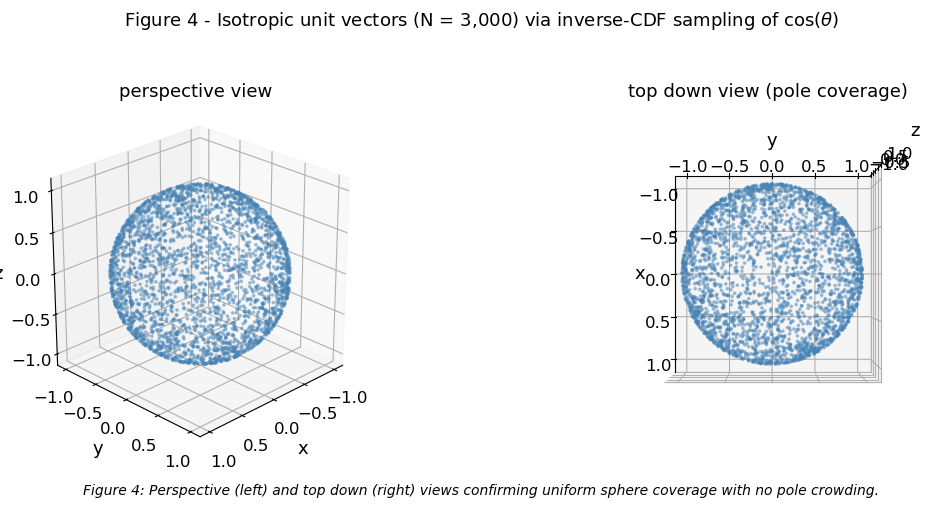

In [34]:
plt.close('all')

def isotropic_unit_vector():
    """
    Generate a single unit vector uniformly distributed on the sphere,
    using inverse-CDF sampling on cos(theta) to avoid pole crowding bias.

    Returns:
        tuple: (x, y, z) Cartesian components with x^2 + y^2 + z^2 = 1.
    """
    # Sample cos(theta) uniformly on [-1, 1].
    # This is the correct marginal distribution: the sphere area element is
    # sin(theta) d(theta) d(phi) = d(cos theta) d(phi), so sampling
    # cos(theta) uniformly gives equal solid-angle coverage at every latitude.
    cos_theta = 1.0 - 2.0 * RNG.next() # maps U[0,1) to [-1, 1]

    # Recover sin(theta) from the Pythagorean identity
    sin_theta = np.sqrt(1.0 - cos_theta * cos_theta)

    # Sample the azimuthal angle phi uniformly on [0, 2*pi).
    phi = 2.0 * np.pi * RNG.next()

    # Convert spherical polar to Cartesian coordinates.
    return (sin_theta * np.cos(phi),
            sin_theta * np.sin(phi),
            cos_theta)


# Numerical verification:
N_SPHERE = 3000
sphere_pts = np.array([isotropic_unit_vector() for _ in range(N_SPHERE)])
# Every row must have unit magnitude, any deviation is a floating point error
magnitudes = np.linalg.norm(sphere_pts, axis=1)
print(f'Mean |r| over {N_SPHERE} vectors: {magnitudes.mean():.6f}  (expected 1.000000)')
print(f'Maximum ||r| - 1|: {np.abs(magnitudes - 1).max():.2e}  (computer precision)')

# Visual verification:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
view_angles = [(25, 45), (90, 0)]
view_labels = ['perspective view', 'top down view (pole coverage)']

for ax, (elev, azim), label in zip(axes, view_angles, view_labels):
    ax.scatter(sphere_pts[:, 0], sphere_pts[:, 1], sphere_pts[:, 2],
               s=3, alpha=0.4, color='steelblue')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(label)
    ax.set_box_aspect([1, 1, 1]) # equal scaling to avoid a distorted sphere

plt.suptitle(f'Figure 4 - Isotropic unit vectors (N = {N_SPHERE:,}) '
             f'via inverse-CDF sampling of cos($\\theta$)', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.text(0.5, 0.01,
         'Figure 4: Perspective (left) and top down (right) views confirming '
         'uniform sphere coverage with no pole crowding.',
         ha='center', fontsize=10, style='italic')
plt.show()


Two checks confirm the correctness. Numerically, every vector has unit magnitude to machine precision ($\sim 10^{-16}$). Visually, the points cover the sphere uniformly with no detectable thickening at the poles. The top down view is most sensitive to pole crowding: the uniform density of points near $z = \pm 1$ confirms that the inverse-CDF method has correctly accounted for the $\sin\theta$ area element.


### 4.2 Combining Direction and Step Length: Isotropic Random Walks

A complete Monte Carlo step combines an exponentially distributed step length with an isotropic direction: $\boldsymbol{\Delta r}_i = s_i\,\hat{\boldsymbol{r}}_i$ with $s_i = -\lambda_T \ln(u_i)$. Five short random walks in water are visualised below to confirm the combined sampler behaves sensibly.


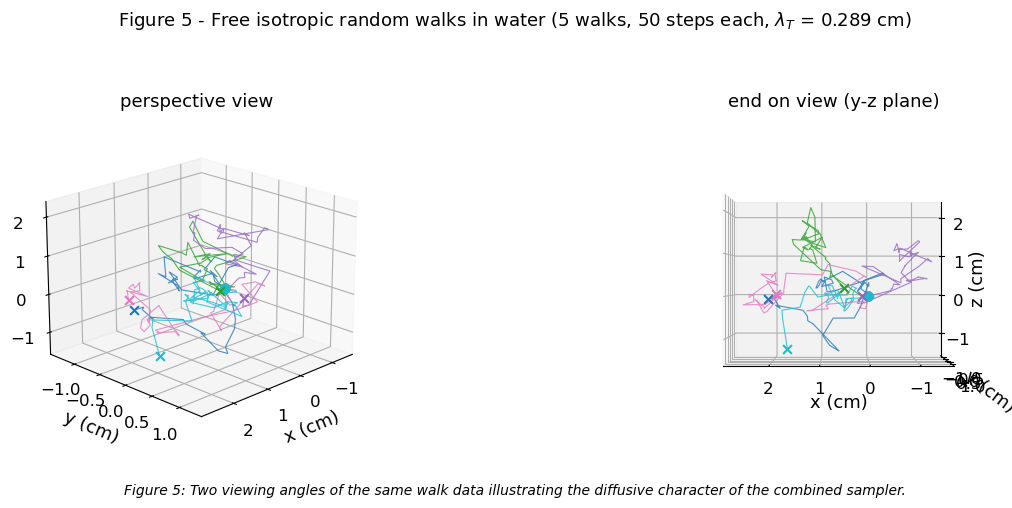

In [35]:
plt.close('all')

def isotropic_step(lamb):
    """
    Generate one random walk displacement: exponentially distributed
    step length multiplied by an isotropic unit direction.

    Args:
        lamb (float): Total mean free path [cm].

    Returns:
        tuple: (dx, dy, dz) displacement components [cm].
    """
    step = -lamb * np.log(RNG.next()) # Exp(lamb) step length
    ux, uy, uz = isotropic_unit_vector() # isotropic unit direction
    return (step * ux, step * uy, step * uz)


N_WALK_STEPS = 50
N_WALKS = 5
lamb_demo = props['Water']['lambda_T'] # water total MFP [cm]
colours = plt.cm.tab10(np.linspace(0, 0.9, N_WALKS))

# Generate and store all paths before plotting so both viewing angles use exactly the same random data.
paths_data = []
for col in colours:
    pos  = np.zeros(3) # each walk starts at the origin
    path = [pos.copy()]
    for _ in range(N_WALK_STEPS):
        dx, dy, dz = isotropic_step(lamb_demo)
        pos += np.array([dx, dy, dz])
        path.append(pos.copy())
    paths_data.append((np.array(path), col))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})
view_angles = [(20, 45), (0, 90)]
view_labels  = ['perspective view', 'end on view (y-z plane)']

for ax, (elev, azim), label in zip(axes, view_angles, view_labels):
    for path, col in paths_data:
        ax.plot(path[:, 0], path[:, 1], path[:, 2], color=col, lw=0.8, alpha=0.8)
        ax.scatter(*path[0], color=col, s=40, marker='o') # start
        ax.scatter(*path[-1], color=col, s=40, marker='x') # end
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x (cm)'); ax.set_ylabel('y (cm)'); ax.set_zlabel('z (cm)')
    ax.set_title(label)

plt.suptitle(f'Figure 5 - Free isotropic random walks in water '
             f'({N_WALKS} walks, {N_WALK_STEPS} steps each, '
             f'$\\lambda_T$ = {lamb_demo:.3f} cm)', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.93])
fig.text(0.5, 0.01,
         'Figure 5: Two viewing angles of the same walk data illustrating the '
         'diffusive character of the combined sampler.',
         ha='center', fontsize=10, style='italic')
plt.show()

The walks in Figure 5 confirm that the combined sampler produces physically sensible trajectories. End points are distributed around the origin with a spread of a few centimetres, consistent with the predicted $\sqrt{N_{\rm steps}}\,\lambda_T \approx 3$ cm diffusion radius. No directional bias is visible in either viewing angle, confirming that isotropic scattering is correctly implemented. The end on view (right) shows end points symmetrically distributed  about the origin in the $y$–$z$ plane, further confirming the absence of any preferred scattering direction.


---
## Section 5 - Full Neutron Transport Simulation

### 5.1 Single-Neutron History Function

The exponential sampler, isotropic direction generator, and absorption/scattering branching are now combined to track a single neutron through a slab of thickness $L$ placed between $x = 0$ and $x = L$. The algorithm implements the following sequence:

1. The neutron enters at $x = 0$ travelling in the $+\hat{x}$ direction (normal incidence, neutrons enter perpendicularly to the left face of the slab).
2. A step length $s_i$ is drawn from the exponential distribution with mean $\lambda_T$.
3. On the first step the direction is fixed as $+\hat{x}$; on subsequent steps it is isotropic.
4. The position is updated. If $x < 0$ the neutron is reflected; if $x > L$ it is transmitted.
5. Otherwise, a uniform random number determines the outcome: below $P_{\rm abs}$ the neutron is absorbed; otherwise it is scattered and the loop continues.

The number of scattering events per history is tracked as a useful diagnostic of moderation strength. The same core function is used by every future analysis, ensuring a single consistent implementation.


In [36]:
def simulate_neutron(L, lamb_T, P_abs, track=False):
    """
    Simulate a single neutron history through a single material slab
    of thickness L.

    Args:
        L      (float): Slab thickness [cm].
        lamb_T (float): Total mean free path [cm].
        P_abs  (float): Probability of absorption per interaction.
        track   (bool): If True, record the full (x,y,z) trajectory.

    Returns:
        outcome (str): 'transmitted', 'reflected', or 'absorbed'.
        n_scatter(int): Number of scattering events undergone.
        trajectory (list|None): List of [x,y,z] positions if track=True, otherwise None.
    """
    x = y = z = 0.0 # neutron starts at the origin (entry face)
    n_scatter = 0 # count scattering events for this history
    first_step = True # flag to enforce normal incidence on the first step
    trajectory = [[x, y, z]] if track else None

    while True:
        # Draw next step length from Exp(lambda_T):
        step = -lamb_T * np.log(RNG.next())

        if first_step:
            # First step: travel along +x (normal incidence)
            dx, dy, dz = step, 0.0, 0.0
            first_step = False
        else:
            # All subsequent steps use isotropic direction on the unit sphere
            ux, uy, uz = isotropic_unit_vector()
            dx, dy, dz = step * ux, step * uy, step * uz

        # Update position:
        x += dx; y += dy; z += dz
        if track:
            trajectory.append([x, y, z])

        # Boundary check:
        # x < 0 : exited back through the entry face (reflected)
        # x > L : reached the far face (transmitted)
        if x < 0.0:
            return 'reflected',   n_scatter, trajectory
        if x > L:
            return 'transmitted', n_scatter, trajectory

        # Interaction decision, the neutron has interacted inside the slab.
        # Draw one more uniform number to decide absorb or scatter
        if RNG.next() < P_abs:
            return 'absorbed', n_scatter, trajectory
        else:
            n_scatter += 1 # scatter: increment and continue the walk


def run_simulation(L, material_props, N):
    """
    Run N independent neutron histories and tally outcomes.

    Args:
        L             (float): Slab thickness [cm].
        material_props (dict): Output of compute_material_properties().
        N               (int): Number of neutron histories.

    Returns:
        dict: Counts (N_T, N_R, N_A), fractions (f_T, f_R, f_A), binomial
              standard errors (sigma_T, sigma_R, sigma_A), mean_scatter.
    """
    lamb_T = material_props['lambda_T']
    P_abs  = material_props['P_abs']

    N_T = N_R = N_A = 0
    total_scatter = 0

    for _ in range(N):
        # Simulate one history, discard trajectory (not needed for bulk stats).
        outcome, n_sc, _ = simulate_neutron(L, lamb_T, P_abs)
        total_scatter += n_sc
        if outcome == 'transmitted':
            N_T += 1
        elif outcome == 'reflected':
            N_R += 1
        else:
            N_A += 1

    f_T = N_T / N;  f_R = N_R / N;  f_A = N_A / N

    # Binomial standard error: sigma_f = sqrt(k*(N-k)/N) / N
    # k is the raw count and N is the total number of histories
    sigma_T = np.sqrt(N_T * (N - N_T) / N) / N
    sigma_R = np.sqrt(N_R * (N - N_R) / N) / N
    sigma_A = np.sqrt(N_A * (N - N_A) / N) / N

    return {
        'N': N, 'N_T': N_T, 'N_R': N_R, 'N_A': N_A,
        'f_T': f_T,'f_R': f_R, 'f_A': f_A,
        'sigma_T': sigma_T, 'sigma_R': sigma_R, 'sigma_A': sigma_A,
        'mean_scatter': total_scatter / N,
    }


print('Simulation functions defined.')


Simulation functions defined.


### 5.2 Visualising Random Walks Through Each Material

Before producing bulk statistics, individual neutron histories through a 10 cm slab of each material are visualised. Trajectories are projected onto the $x$–$y$ plane, colour coded by outcome with slab boundaries marked by dashed vertical lines.


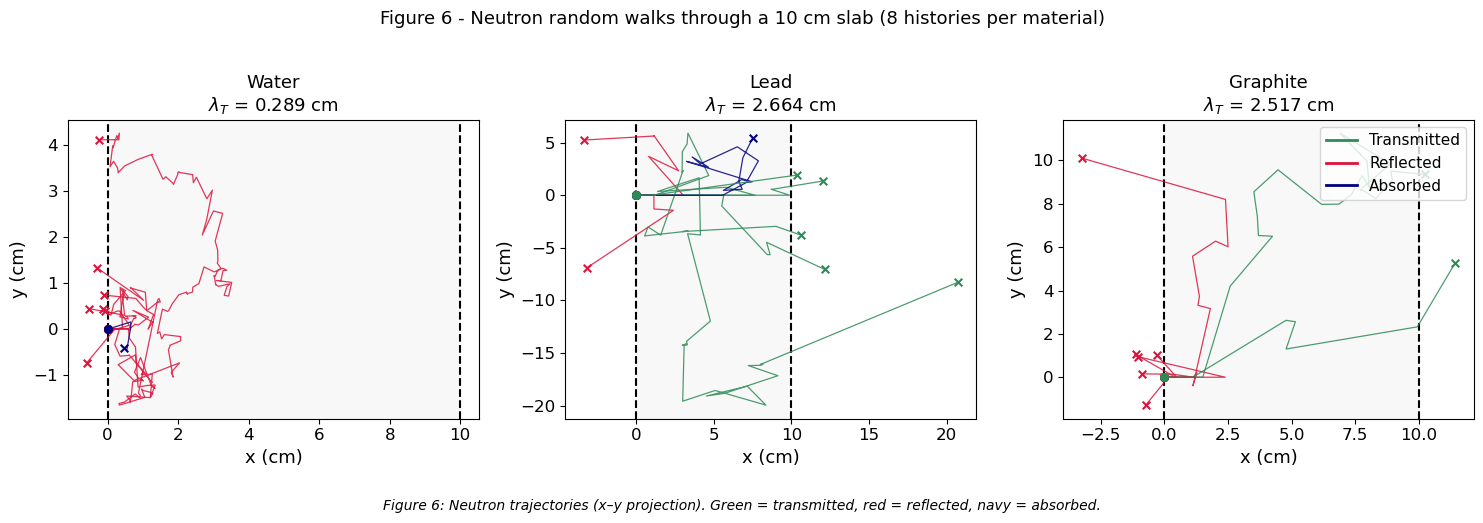

In [37]:
plt.close('all')
N_VIS = 8
L_VIS = 10.0

# Colour code trajectories by physical outcome.
outcome_colours = {
    'transmitted': 'seagreen',
    'reflected': 'crimson',
    'absorbed': 'navy',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, _) in zip(axes, MATERIALS.items()):
    p = props[name]
    ax.axvline(0, color='k', lw=1.5, ls='--', label='Slab boundary')
    ax.axvline(L_VIS, color='k', lw=1.5, ls='--')
    ax.axvspan(0, L_VIS, alpha=0.05, color='grey') # faint shading of slab interior

    for _ in range(N_VIS):
        # track=True records the full (x,y,z) trajectory for plotting.
        outcome, _, traj = simulate_neutron(L_VIS, p['lambda_T'], p['P_abs'], track=True)
        traj = np.array(traj) # list of [x,y,z] rows, 2D array
        col = outcome_colours[outcome]
        ax.plot(traj[:, 0], traj[:, 1], color=col, lw=0.9, alpha=0.85)
        ax.scatter(traj[0, 0], traj[0, 1], color=col, s=30, zorder=5) # start
        ax.scatter(traj[-1, 0], traj[-1, 1], color=col, s=30, marker='x', zorder=5) # end

    ax.set_xlabel('x (cm)')
    ax.set_ylabel('y (cm)')
    ax.set_title(f'{name}\n$\\lambda_T$ = {p["lambda_T"]:.3f} cm')

legend_handles = [Line2D([0], [0], color=c, lw=2, label=o.capitalize())
                  for o, c in outcome_colours.items()]
axes[-1].legend(handles=legend_handles, loc='upper right')

plt.suptitle(f'Figure 6 - Neutron random walks through a {L_VIS:.0f} cm slab '
             f'({N_VIS} histories per material)', fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 6: Neutron trajectories (x–y projection). '
         'Green = transmitted, red = reflected, navy = absorbed.',
         ha='center', fontsize=10, style='italic')
plt.show()


The qualitative differences between materials are immediately apparent. Water trajectories are short, dense and convoluted. the sub-half-centimetre mean free path forces many interactions within the first few centimetres, and most histories end in reflection or absorption before traversing the full 10 cm. Lead and graphite trajectories are visibly longer and straighter, with some histories spanning the full slab on nearly direct paths. The colour distribution is consistent with the numerical results in Section 5.3: water is overwhelmingly red and navy, while graphite shows a greater proportion of green transmitted trajectories.


### 5.3 Fixed Thickness Results: $L = 10$ cm with $N = 10{,}000$ Neutrons

The full simulation is run with $N = 10{,}000$ neutron histories per material at the thickness of 10 cm. Transmission, reflection, and absorption rates are reported with their binomial standard errors, $\sigma_{f} = \sqrt{\hat{p}(1-\hat{p})/N}$, where $\hat{p} = k/N$ is the estimated fraction and $k$ is the raw count for the relevant channel.


In [38]:
t_start = time.time()

fixed_results = {
    name: run_simulation(L_FIXED, props[name], N=N_FIXED) for name in MATERIALS
}
t_elapsed = time.time() - t_start
print(f'Fixed-thickness simulations ({N_FIXED:,} neutrons x 3 materials) '
      f'completed in {t_elapsed:.2f} s\n')

for name, r in fixed_results.items():
    print('-' * 55)
    print(f' Transmission Through {L_FIXED:.0f} cm - {name}')
    print('-' * 55)
    print(f'  Total neutrons simulated : {r["N"]:>8,}')
    print(f'  Neutrons transmitted     : {r["N_T"]:>8,}  '
          f'({r["f_T"]*100:5.2f} +/- {r["sigma_T"]*100:.2f} %)')
    print(f'  Neutrons reflected       : {r["N_R"]:>8,}  '
          f'({r["f_R"]*100:5.2f} +/- {r["sigma_R"]*100:.2f} %)')
    print(f'  Neutrons absorbed        : {r["N_A"]:>8,}  '
          f'({r["f_A"]*100:5.2f} +/- {r["sigma_A"]*100:.2f} %)')
    print(f'  Mean scattering events   : {r["mean_scatter"]:>8.2f}')
    print()

# Conservation check:
# Every neutron ends in exactly one outcome, so f_T + f_R + f_A must equal 1.
# Verifying this explicitly acts as a cheap sanity check on the tallying logic.
print('Conservation check - f_T + f_R + f_A must equal 1:')
for name, r in fixed_results.items():
    total = r['f_T'] + r['f_R'] + r['f_A']
    print(f'  {name:<10}: {total:.10f}')


Fixed-thickness simulations (10,000 neutrons x 3 materials) completed in 3.40 s

-------------------------------------------------------
 Transmission Through 10 cm - Water
-------------------------------------------------------
  Total neutrons simulated :   10,000
  Neutrons transmitted     :       33  ( 0.33 +/- 0.06 %)
  Neutrons reflected       :    7,943  (79.43 +/- 0.40 %)
  Neutrons absorbed        :    2,024  (20.24 +/- 0.40 %)
  Mean scattering events   :    31.49

-------------------------------------------------------
 Transmission Through 10 cm - Lead
-------------------------------------------------------
  Total neutrons simulated :   10,000
  Neutrons transmitted     :    2,863  (28.63 +/- 0.45 %)
  Neutrons reflected       :    6,083  (60.83 +/- 0.49 %)
  Neutrons absorbed        :    1,054  (10.54 +/- 0.31 %)
  Mean scattering events   :     7.20

-------------------------------------------------------
 Transmission Through 10 cm - Graphite
---------------------------

### 5.4 Discussion of Fixed-Thickness Results

Three distinct physical behaviours emerge from these results, each reflecting the underlying nuclear properties tabulated in Section 3.2.

Water is by far the most effective shield. With a sub-half-centimetre total mean free path, neutrons are scattered many times within the first few centimetres and have ample opportunity to be either absorbed or reflected back out the entry face. The high mean scatter count reflects this - despite scattering being far more probable than absorption per interaction ($P_{\rm scat} \approx 0.994$), the sheer frequency of interactions ensures absorption eventually dominates for neutrons that do not promptly escape.

Lead behaves as an intermediate case. Its longer mean free path of 2.7 cm allows roughly $L/\lambda_T \approx 3.7$ mean free paths to fit within a 10 cm slab, so most neutrons interact a few times before either reaching the far face or being absorbed. The transmission fraction is correspondingly higher than for water, while the lower frequency of interactions also reduces the probability of scattering back out.

Graphite is the most scattering dominated of the three, with $P_{\rm abs}$ below 0.001. Almost no neutron is permanently captured per interaction, so the dominant fate at this thickness is escape via transmission or reflection rather than absorption. This near perfect scattering behaviour is why graphite is used as a moderator in nuclear reactors: it slows neutrons through repeated elastic collisions without removing them from the population [5].


---
## Section 6 - Variation of Rates with Slab Thickness

### 6.1 Sweeping the Slab Thickness

Transmission, reflection, and absorption rates are computed as functions of slab thickness $L$, sweeping from 0 to 20 cm in 0.5 cm steps. To keep the runtime manageable, the per-point sample size is reduced to $N = 1{,}000$ neutrons; this gives uncertainty of order $\sim 1.5\%$ on each fraction, which is adequate for visualising trends and for the subsequent attenuation length fits. The 0-20 cm range is wide enough to capture meaningful exponential decay in all three materials while avoiding the regime where water's transmission falls below the per-point statistical uncertainty.


In [39]:
def thickness_sweep(thicknesses, material_props, N):
    """
    Run the neutron simulation across a range of slab thicknesses.

    Args:
        thicknesses    (array): 1-D array of slab thicknesses [cm].
        material_props  (dict): Output of compute_material_properties().
        N                (int): Number of neutron histories per thickness.

    Returns:
        dict: Arrays of f_T, f_R, f_A, their uncertainties, and mean
              scatter count, each with one entry per thickness.
    """
    n_pts = len(thicknesses)
    # Pre-allocate one output value per thickness point.
    f_T_arr = np.zeros(n_pts); s_T_arr = np.zeros(n_pts)
    f_R_arr = np.zeros(n_pts); s_R_arr = np.zeros(n_pts)
    f_A_arr = np.zeros(n_pts); s_A_arr = np.zeros(n_pts)
    ms_arr = np.zeros(n_pts)

    for i, L in enumerate(thicknesses):
        r = run_simulation(L, material_props, N=N)
        f_T_arr[i] = r['f_T']; f_R_arr[i] = r['f_R']; f_A_arr[i] = r['f_A']
        s_T_arr[i] = r['sigma_T']; s_R_arr[i] = r['sigma_R']; s_A_arr[i] = r['sigma_A']
        ms_arr[i] = r['mean_scatter']

    return {
        'f_T': f_T_arr, 'f_R': f_R_arr, 'f_A': f_A_arr,
        'sigma_T': s_T_arr, 'sigma_R': s_R_arr, 'sigma_A': s_A_arr,
        'mean_scatter': ms_arr,
    }


L_values = np.arange(0, L_MAX + L_STEP, L_STEP) # 0, 0.5, 1.0, ..., L_MAX

t_start = time.time()
sweep_results = {}
for name in MATERIALS:
    print(f'Running thickness sweep for {name}')
    sweep_results[name] = thickness_sweep(L_values, props[name], N=N_SWEEP)

print(f'\nThickness sweeps (0–{L_MAX:.0f} cm, {len(L_values)} points x {N_SWEEP:,} neutrons) '
      f'completed in {time.time()-t_start:.1f} s')

Running thickness sweep for Water
Running thickness sweep for Lead
Running thickness sweep for Graphite

Thickness sweeps (0–20 cm, 41 points x 1,000 neutrons) completed in 13.6 s


### 6.2 Plotting Variation with Thickness

Figure 7 shows the transmission, reflection, and absorption rates as functions of slab thickness $L$ for all three materials, with binomial error bars.


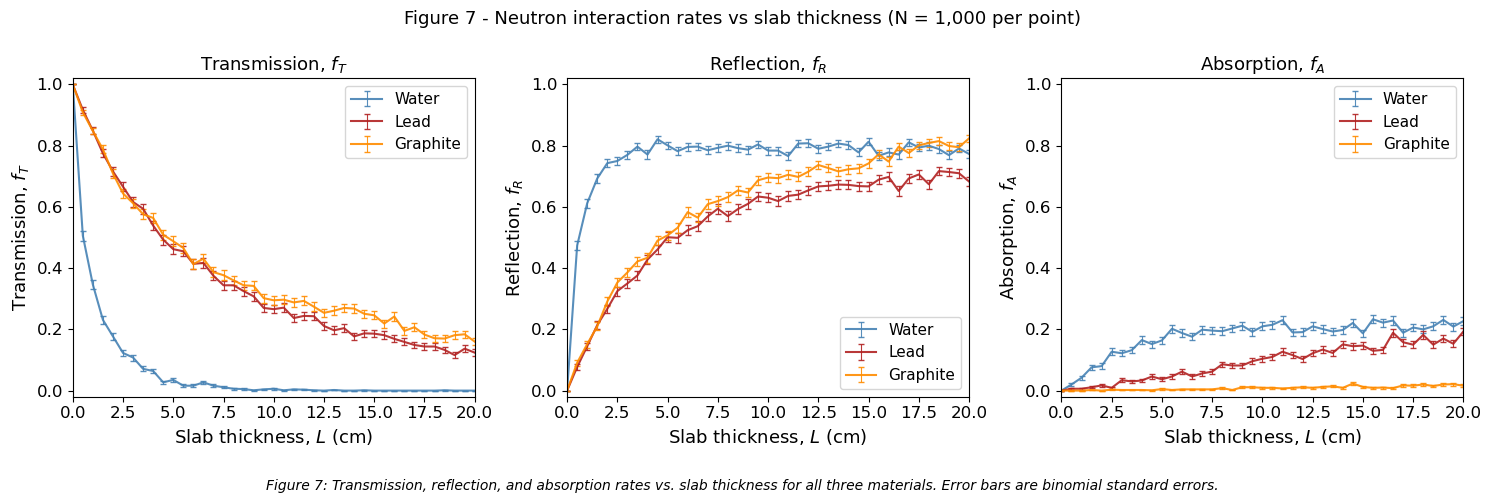

In [40]:
plt.close('all')

# Consistent colour per material across all remaining figures.
mat_colours = {
    'Water': 'steelblue',
    'Lead': 'firebrick',
    'Graphite': 'darkorange',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Transmission, $f_T$', 'Reflection, $f_R$', 'Absorption, $f_A$']
keys = [('f_T', 'sigma_T'), ('f_R', 'sigma_R'), ('f_A', 'sigma_A')]

for ax, title, (fkey, skey) in zip(axes, titles, keys):
    for name, col in mat_colours.items():
        r = sweep_results[name]
        ax.errorbar(L_values, r[fkey], yerr=r[skey],
                    color=col, lw=1.5, elinewidth=0.8, capsize=2,
                    label=name, alpha=0.9)
    ax.set_xlabel('Slab thickness, $L$ (cm)')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, L_MAX)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle(f'Figure 7 - Neutron interaction rates vs slab thickness '
             f'(N = {N_SWEEP:,} per point)', fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 7: Transmission, reflection, and absorption rates vs. slab thickness '
         'for all three materials. Error bars are binomial standard errors.',
         ha='center', fontsize=10, style='italic')
plt.show()


Figure 7 reveals three physically distinct behaviours. Transmission decays approximately exponentially in all three materials, with water falling to near-zero within the first few centimetres and graphite retaining a significant transmitted fraction across the full 20 cm range, consistent with the differences in $\lambda_T$ tabulated in Section 3.2. Reflection rises sharply from zero at small $L$ then saturates once the slab is thick enough that virtually no neutron can traverse without scattering: this saturation occurs below 5 cm for water but at considerably greater thickness for lead and graphite. Absorption saturates more slowly and at a lower asymptotic value for graphite than for the other two materials, reflecting its extremely small $P_{\rm abs}$: in graphite most neutrons that fail to transmit escape by reflection rather than capture, whereas water and lead convert a substantial fraction into absorptions.


---
## Section 7 - Characteristic Attenuation Lengths

### 7.1 Fitting Procedure

For each material, the transmission fraction is expected to decay approximately exponentially with slab thickness: $f_T(L) \approx A\,e^{-L/\Lambda}$, where $\Lambda$ is the characteristic attenuation length. Taking logarithms gives $\ln f_T = \ln A - L/\Lambda$, which is fitted by `np.polyfit` to extract the gradient and hence $\Lambda = -1/\text{gradient}$.

The fit is weighted because each thickness point has a different statistical uncertainty. By error propagation, $\sigma_{\ln f_T} = \sigma_{f_T}/f_T$, and the appropriate weight in `polyfit` (which expects $w \propto 1/\sigma$) is $w_i = f_{T,i}/\sigma_{f_T,i}$. Points where $f_T = 0$ (log undefined) and the $L = 0$ point (trivially $f_T = 1$, carrying no gradient information) are excluded. The error on the attenuation length follows from error propagation as $\sigma_\Lambda = \Lambda^2 \sigma_m$, where $\sigma_m$ is the standard error on the gradient from `polyfit`'s covariance matrix.


In [41]:
def fit_attenuation_length(L_arr, f_T_arr, sigma_T_arr):
    """
    Fit the characteristic attenuation length Lambda from weighted
    log-linear regression of transmission vs. thickness data.

    Excludes the L=0 point (trivially f_T=1) and any points where
    f_T=0 (log undefined).

    Args:
        L_arr       (array): Slab thicknesses [cm].
        f_T_arr     (array): Transmission fractions.
        sigma_T_arr (array): Statistical uncertainties on f_T.

    Returns:
        Lambda       (float): Fitted attenuation length [cm].
        sigma_Lambda (float): Uncertainty on Lambda [cm].
        coeffs       (array): Polynomial coefficients [gradient, intercept].
    """
    # Exclude the trivial L=0 point and any bins with f_T=0.
    mask = (f_T_arr > 0) & (L_arr > 0)
    x = L_arr[mask]
    y = np.log(f_T_arr[mask]) # linearise (ln(f_T) = ln(A) - L/Lambda)

    # Weight = f_T / sigma_T = 1 / sigma_{ln f}: well measured points drive the fit.
    # Replace non finite weights (e.g. where sigma_T=0) with zero to exclude them.
    weights = f_T_arr[mask] / sigma_T_arr[mask]
    weights = np.where(np.isfinite(weights), weights, 0.0)

    # cov=True returns the covariance matrix of the fitted coefficients
    coeffs, cov = np.polyfit(x, y, 1, w=weights, cov=True)
    gradient = coeffs[0] # slope = -1/Lambda
    Lambda = -1.0 / gradient # characteristic attenuation length
    # Error propagation: sigma_Lambda = Lambda^2 * sigma_gradient
    sigma_Lambda = Lambda**2 * np.sqrt(cov[0, 0])
    return Lambda, sigma_Lambda, coeffs


fit_results = {}
for name in MATERIALS:
    r = sweep_results[name]
    Lambda, sigma_Lambda, coeffs = fit_attenuation_length(L_values, r['f_T'], r['sigma_T'])
    fit_results[name] = {'Lambda': Lambda, 'sigma_Lambda': sigma_Lambda, 'coeffs': coeffs}

# Summary table:
print(f"{'Material':<12} {'Lambda_fit (cm)':>16} {'sigma_L (cm)':>14} "
      f"{'lambda_T (cm)':>14} {'lambda_a (cm)':>14}")
print('-' * 74)
for name, fr in fit_results.items():
    p = props[name]
    print(f"{name:<12} {fr['Lambda']:>16.3f} {fr['sigma_Lambda']:>14.3f} "
          f"{p['lambda_T']:>14.4f} {p['lambda_a']:>14.2f}")


Material      Lambda_fit (cm)   sigma_L (cm)  lambda_T (cm)  lambda_a (cm)
--------------------------------------------------------------------------
Water                   1.812          0.070         0.2886          44.97
Lead                    8.748          0.192         2.6640         191.86
Graphite               10.495          0.338         2.5172        2653.99


For all three materials, the fitted attenuation length $\Lambda$ is substantially smaller than both the total mean free path $\lambda_T$ and the absorption-only mean free path $\lambda_a$. In a finite slab where scattering dominates, neutrons are not only absorbed but also reflected back out the entry face, so the effective attenuation is much stronger than either cross-section alone would predict. The ratio $\Lambda/\lambda_a$ is extremely small for graphite and the most dramatic demonstration that scattering induced reflection is the dominant loss mechanism when $\Sigma_s \gg \Sigma_a$. The goodness-of-fit of the exponential model is assessed in Figure 9 below.


### 7.2 Comparison with Pure Absorption (Beer-Lambert) Prediction

If only absorption mattered (no scattering), neutron transport would obey the Beer–Lambert law $f_T = e^{-L/\lambda_a}$. The naive expectation is that adding scattering can only redirect neutrons rather than remove them, so the apparent attenuation length should be at least as long as $\lambda_a$. However in a finite slab geometry, the situation is reversed.

The key point is that scattering offers two routes for a neutron to leave the slab without being absorbed: continuing forward (transmission) or being scattered back through the entry face (reflection). Reflection is a loss channel for the transmitted beam that does not exist in the pure absorption picture. For materials where scattering dominates absorption (holds for all three materials here) reflection becomes the dominant loss mechanism, giving $\Lambda \ll \lambda_a$.

Figure 8 overlays the Monte Carlo data and fitted line with the Beer-Lambert prediction for each material. Figure 9 shows the normalised residuals from the exponential fit, which are a direct check of whether the single exponential model is statistically adequate.


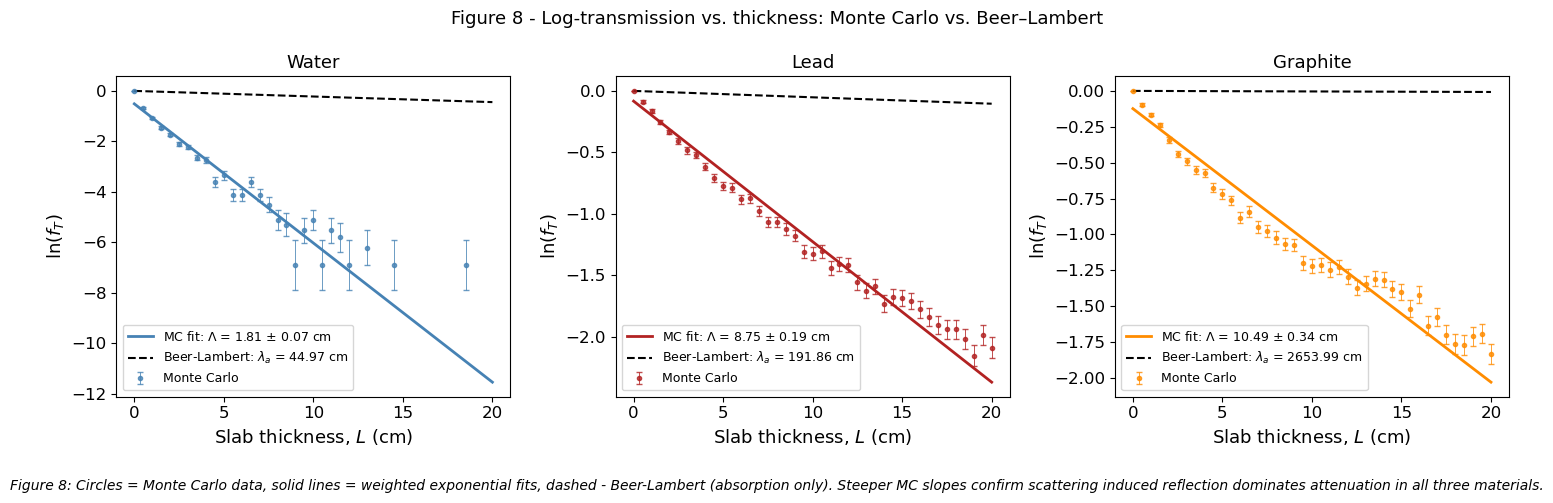

In [42]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, col) in zip(axes, mat_colours.items()):
    r = sweep_results[name]
    fr = fit_results[name]
    lamb_a = props[name]['lambda_a'] # absorption only MFP for Beer-Lambert reference

    mask = r['f_T'] > 0
    # Error bars in log space: sigma_{ln f} = sigma_f / f (error propagation)
    ax.errorbar(L_values[mask], np.log(r['f_T'][mask]),
               yerr=r['sigma_T'][mask] / r['f_T'][mask],
               fmt='o', ms=3, color=col, elinewidth=0.7, capsize=2,
               label='Monte Carlo', alpha=0.8)

    x_line = np.linspace(0, L_MAX, 300)

    # Monte Carlo fitted line: gradient = -1/Lambda from the attenuation fit.
    ax.plot(x_line, np.polyval(fr['coeffs'], x_line), color=col, lw=2,
            label=f'MC fit: $\\Lambda$ = {fr["Lambda"]:.2f} $\\pm$ {fr["sigma_Lambda"]:.2f} cm')

    # Beer-Lambert reference using the absorption-only MFP.
    ax.plot(x_line, -x_line / lamb_a, 'k--', lw=1.5,
            label=f'Beer-Lambert: $\\lambda_a$ = {lamb_a:.2f} cm')

    ax.set_xlabel('Slab thickness, $L$ (cm)')
    ax.set_ylabel('ln($f_T$)')
    ax.set_title(name)
    ax.legend(fontsize=9)

plt.suptitle('Figure 8 - Log-transmission vs. thickness: Monte Carlo vs. Beer–Lambert', fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 8: Circles = Monte Carlo data, solid lines = weighted exponential fits, '
         'dashed - Beer-Lambert (absorption only). Steeper MC slopes confirm '
         'scattering induced reflection dominates attenuation in all three materials.',
         ha='center', fontsize=10, style='italic')
plt.show()


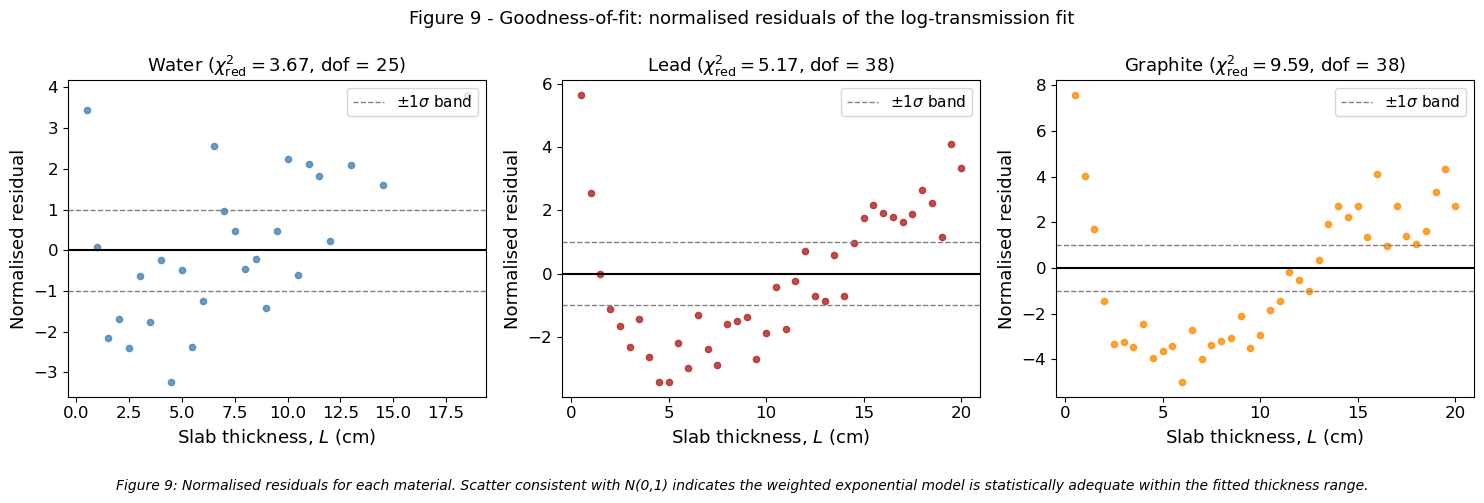

In [43]:
# Figure 9: Goodness-of-fit - normalised residuals and reduced chi-squared:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, col) in zip(axes, mat_colours.items()):
    r = sweep_results[name]
    fr = fit_results[name]

    # Use the same mask as the fit: exclude L=0 and f_T=0 points.
    mask = (r['f_T'] > 0) & (L_values > 0)
    x = L_values[mask]
    y_fit = np.polyval(fr['coeffs'], x) # fitted log-transmission
    y_data = np.log(r['f_T'][mask]) # observed log-transmission
    # Uncertainty on ln(f_T) by error propagation: sigma_{ln f} = sigma_f / f
    sigma_log = r['sigma_T'][mask] / r['f_T'][mask]

    # Normalised residuals: (observed - fitted) / uncertainty.
    # Under H0 (exponential model correct) these should scatter as N(0,1).
    residuals = (y_data - y_fit) / sigma_log

    # Reduced chi-squared from the sum of squared normalised residuals.
    dof = len(x) - 2 # two fitted parameters: slope and intercept
    chi2_red = np.sum(residuals**2) / dof

    ax.scatter(x, residuals, s=20, color=col, alpha=0.8)
    ax.axhline(0, color='k', lw=1.5) # zero reference line
    ax.axhline(+1, color='grey', lw=1, ls='--', label=r'$\pm 1\sigma$ band')
    ax.axhline(-1, color='grey', lw=1, ls='--')
    ax.set_xlabel('Slab thickness, $L$ (cm)')
    ax.set_ylabel('Normalised residual')
    ax.set_title(f'{name} ($\\chi^2_{{\\rm red}} = {chi2_red:.2f}$, dof = {dof})')
    ax.legend(loc='upper right')

plt.suptitle('Figure 9 - Goodness-of-fit: normalised residuals of the log-transmission fit', fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 9: Normalised residuals for each material. '
         'Scatter consistent with N(0,1) indicates the weighted exponential model '
         'is statistically adequate within the fitted thickness range.',
         ha='center', fontsize=10, style='italic')
plt.show()


For all three materials, the fitted attenuation length $\Lambda$ is much smaller than the absorption only mean free path $\lambda_a$. The graphite case is the most striking: $\lambda_a$ exceeds 26 metres, yet $\Lambda$ is only of order 10 cm (a consequence of the extremely high scattering to absorption ratio). A naive Beer-Lambert calculation using $\lambda_a$ alone would predict essentially zero attenuation across 10 cm of graphite, whereas the simulation correctly shows that the majority of incident neutrons fail to traverse the slab.

The residual plots in Figure 9 show $\chi^2_{\rm red}$ values in the range 3–10, indicating that the single-exponential model is a reasonable but imperfect description of the log-transmission data. The systematic scatter at large $L$ (where the residuals deviate more strongly from the $\pm 1\sigma$ band) reflects the fact that the decay of $f_T$ becomes slightly sub-exponential as multiple scattering contributions accumulate at thick slabs.


---
## Section 8 - Mean Number of Scattering Events

Beyond the headline transmission, reflection, and absorption fractions, the mean number of scattering events per neutron history is a useful diagnostic of how strongly each material moderates the neutron flux. Figure 10 shows how this quantity evolves with slab thickness. Within a thin slab ($L < \lambda_T$) the value rises roughly linearly with $L$ as the neutron has more material in which to scatter; as $L$ grows large the mean scatter count saturates at a material specific asymptote governed by $P_{\rm abs}$.


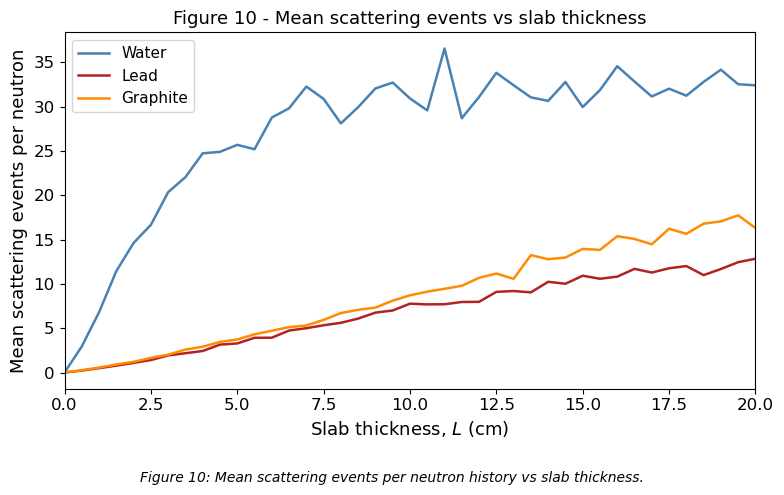

Mean scattering events at L = 10 cm:
 Water     : 30.94
 Lead      : 7.77
 Graphite  : 8.72


In [44]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 5))

for name, col in mat_colours.items():
    r = sweep_results[name]
    ax.plot(L_values, r['mean_scatter'], color=col, lw=1.8, label=name)

ax.set_xlabel('Slab thickness, $L$ (cm)')
ax.set_ylabel('Mean scattering events per neutron')
ax.set_title('Figure 10 - Mean scattering events vs slab thickness')
ax.legend()
ax.set_xlim(0, L_MAX)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 10: Mean scattering events per neutron history vs slab thickness.',
         ha='center', fontsize=10, style='italic')
plt.show()

idx_10 = np.argmin(np.abs(L_values - L_FIXED)) # index nearest to L = 10 cm
print(f'Mean scattering events at L = {L_FIXED:.0f} cm:')
for name in MATERIALS:
    print(f' {name:<10}: {sweep_results[name]["mean_scatter"][idx_10]:.2f}')


Water dominates the mean scatter count at every thickness because of its large $\Sigma_s$ - neutrons interact very frequently and most interactions are scattering events. Graphite produces a modest but non-trivial mean scatter count despite having the smallest total cross-section: since $P_{\rm abs}$ is so small, each interaction almost always scatters rather than absorbs, allowing scatters to accumulate over many steps before the history terminates. Lead falls between the two: fewer interactions per unit path length than water, but higher $P_{\rm abs}$ than graphite so histories terminate sooner.

---
## Section 9 - Convergence Analysis

A defining feature of Monte Carlo simulations is that the statistical uncertainty on any sample mean scales as $\sigma \propto 1/\sqrt{N}$. Verifying this scaling explicitly serves as a strong validity check on the simulation. The convergence study is performed for water at $L = 10$ cm, sweeping $N$ from 100 to roughly 50000 across 15 logarithmically spaced points.


Running convergence study for water at L = 10 cm


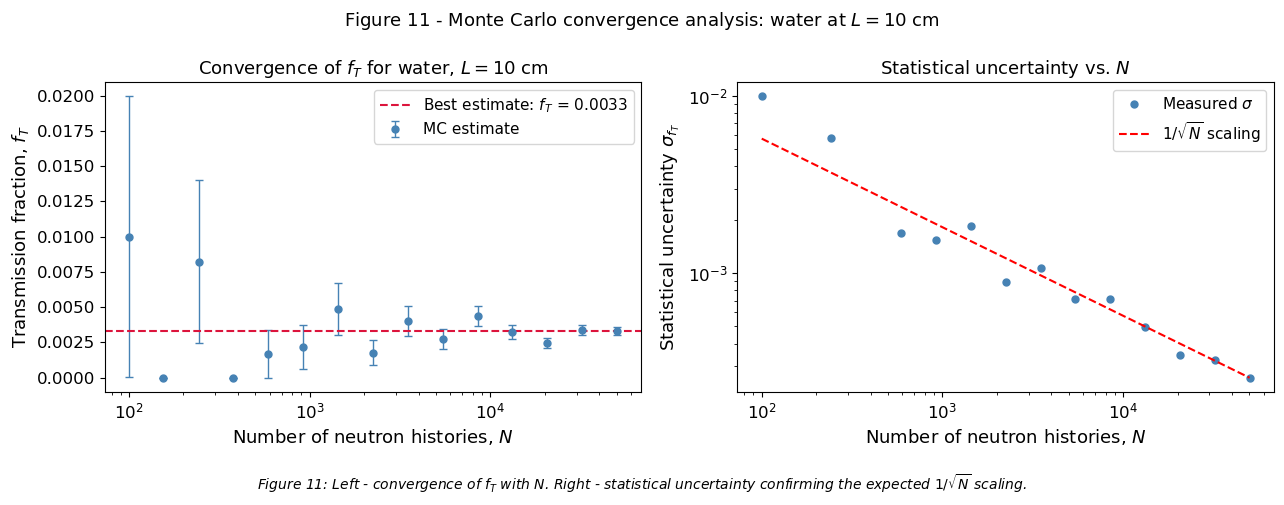

In [45]:
def convergence_study(L, material_props, N_values):
    """
    Measure how the Monte Carlo estimate of f_T and its uncertainty
    change as the number of neutron histories N varies.

    Args:
        L             (float): Slab thickness [cm].
        material_props (dict): Output of compute_material_properties().
        N_values      (array): Integer sample sizes to test.

    Returns:
        f_T_arr   (np.ndarray): f_T estimate at each N.
        sigma_arr (np.ndarray): Uncertainty on f_T at each N.
    """
    f_T_arr = np.zeros(len(N_values))
    sigma_arr = np.zeros(len(N_values))
    for i, N_val in enumerate(N_values):
        res = run_simulation(L, material_props, N=int(N_val))
        f_T_arr[i] = res['f_T']
        sigma_arr[i] = res['sigma_T']
    return f_T_arr, sigma_arr


plt.close('all')
N_values = np.logspace(2, 4.7, 15).astype(int) # 15 log-spaced sizes from 100 to ~50000

print('Running convergence study for water at L = 10 cm')
f_T_conv, sigma_conv = convergence_study(L_FIXED, props['Water'], N_values)

f_T_ref = f_T_conv[-1] # use the largest N run as the best available estimate

# Theoretical 1/sqrt(N) curve, anchored to the largest N sigma.
N_theory = np.logspace(2, 4.7, 200)
sigma_theory = sigma_conv[-1] * np.sqrt(N_values[-1] / N_theory)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: f_T estimate converging to a stable value as N increases.
axes[0].errorbar(N_values, f_T_conv, yerr=sigma_conv, fmt='o', ms=5,
                color='steelblue', elinewidth=1, capsize=3, label='MC estimate')
axes[0].axhline(f_T_ref, color='crimson', lw=1.5, ls='--',
                label=f'Best estimate: $f_T$ = {f_T_ref:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of neutron histories, $N$')
axes[0].set_ylabel('Transmission fraction, $f_T$')
axes[0].set_title('Convergence of $f_T$ for water, $L = 10$ cm')
axes[0].legend()

# Right: log-log plot of sigma vs N, slope must be -1/2.
axes[1].loglog(N_values, sigma_conv, 'o', ms=5, color='steelblue', label='Measured $\\sigma$')
axes[1].loglog(N_theory, sigma_theory, 'r--', lw=1.5, label='$1/\\sqrt{N}$ scaling')
axes[1].set_xlabel('Number of neutron histories, $N$')
axes[1].set_ylabel('Statistical uncertainty $\\sigma_{f_T}$')
axes[1].set_title('Statistical uncertainty vs. $N$')
axes[1].legend()

plt.suptitle('Figure 11 - Monte Carlo convergence analysis: water at $L = 10$ cm',
             fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 11: Left - convergence of $f_T$ with $N$. '
         'Right - statistical uncertainty confirming the expected $1/\\sqrt{N}$ scaling.',
         ha='center', fontsize=10, style='italic')
plt.show()

The right-hand panel of Figure 11 confirms the expected $1/\sqrt{N}$ scaling for $N$ varying from $100$ to $50000$: measured uncertainties fall along the predicted dashed line. The left-hand panel shows that estimates of $f_T$ are noisy at small $N$ (fluctuating by several percent for $N \lesssim 1{,}000$) but settle into a tight cluster around the best-estimate value once $N$ exceeds a few thousand. This empirically justifies the choice of $N = 10{,}000$ for the main results (sub-percent uncertainty) while confirming that $N = 1{,}000$ remains adequate for the thickness sweep, where percent-level error is small compared to the variation between adjacent thickness points.


---
## Section 10 - Summary of Results

The code cell below dynamically generates a summary of the principal numerical results for each material, pulling all values directly from the computed results dictionaries.

In [46]:
for name in MATERIALS:
    r = fixed_results[name]
    fr = fit_results[name]
    p = props[name]
    print(
        f'For {name} (lambda_T = {p["lambda_T"]:.4f} cm, '
        f'lambda_a = {p["lambda_a"]:.2f} cm):\n'
        f'  At L = 10 cm: '
        f'f_T = {r["f_T"]*100:.2f} +/- {r["sigma_T"]*100:.2f} %, '
        f'f_R = {r["f_R"]*100:.2f} +/- {r["sigma_R"]*100:.2f} %, '
        f'f_A = {r["f_A"]*100:.2f} +/- {r["sigma_A"]*100:.2f} %.\n'
        f'  Mean scattering events: {r["mean_scatter"]:.1f}.\n'
        f'  Fitted attenuation length: '
        f'Lambda = {fr["Lambda"]:.2f} +/- {fr["sigma_Lambda"]:.2f} cm '
        f'(Lambda/lambda_a = {fr["Lambda"]/p["lambda_a"]:.3f}).\n'
    )


For Water (lambda_T = 0.2886 cm, lambda_a = 44.97 cm):
  At L = 10 cm: f_T = 0.33 +/- 0.06 %, f_R = 79.43 +/- 0.40 %, f_A = 20.24 +/- 0.40 %.
  Mean scattering events: 31.5.
  Fitted attenuation length: Lambda = 1.81 +/- 0.07 cm (Lambda/lambda_a = 0.040).

For Lead (lambda_T = 2.6640 cm, lambda_a = 191.86 cm):
  At L = 10 cm: f_T = 28.63 +/- 0.45 %, f_R = 60.83 +/- 0.49 %, f_A = 10.54 +/- 0.31 %.
  Mean scattering events: 7.2.
  Fitted attenuation length: Lambda = 8.75 +/- 0.19 cm (Lambda/lambda_a = 0.046).

For Graphite (lambda_T = 2.5172 cm, lambda_a = 2653.99 cm):
  At L = 10 cm: f_T = 30.74 +/- 0.46 %, f_R = 68.36 +/- 0.47 %, f_A = 0.90 +/- 0.09 %.
  Mean scattering events: 8.4.
  Fitted attenuation length: Lambda = 10.49 +/- 0.34 cm (Lambda/lambda_a = 0.004).



Taken together, these results establish water as the most effective neutron shield per unit thickness among the three materials studied, with near complete attenuation within 10 cm. Lead is a clear second, attenuating well but at a slower rate because of its longer mean free path. Graphite is the weakest absorber by a wide margin, yet still attenuates a substantial fraction of incident neutrons via reflection rather than capture, which makes it valuable as a moderator rather than a shield. In every case the fitted attenuation length $\Lambda$ is much shorter than the absorption-only mean free path $\lambda_a$, demonstrating that scattering induced reflection is the dominant loss mechanism in finite slabs of these materials.


---
## Section 11 - Shielding Optimisation

A practical question in nuclear shielding design is: given a fixed total thickness, can performance be improved by combining materials in a sandwich configuration rather than using a single material? The most basic version is addressed here: with a total thickness of 20 cm split evenly into two 10 cm layers, which two material combination yields the lowest transmission? Comparison is made against single material 20 cm slabs as a baseline. For each two material combination, only one ordering is tested here; the ordering effect is addressed in Section 12.

The Woodcock fictitious-tracking method is used for the two material simulations (functions defined below in Section 11). A naive implementation (sampling the full step length from the material at the step's starting position) introduces a systematic error whenever a step straddles the boundary: part of the path is drawn from the wrong exponential distribution. The Woodcock method eliminates this by drawing all steps from a single majorant distribution and applying a real vs fictitious acceptance test at each endpoint. Boundary crossings need no special handling.


In [47]:
def simulate_neutron_woodcock(L1, L2, props1, props2):
    """
    Simulate one neutron through two adjacent slabs using the Woodcock
    (fictitious / delta) tracking method.

    Step lengths are drawn from the majorant exponential distribution
    Sigma_max = max(Sigma_T1, Sigma_T2).  At each step endpoint, the
    interaction is real with probability Sigma_local / Sigma_max, and
    fictitious (no-op) otherwise.  This correctly handles the material
    boundary without any geometric intersection calculation.

    Args:
        L1     (float): Thickness of slab 1 [cm].
        L2     (float): Thickness of slab 2 [cm].
        props1  (dict): Material properties of slab 1.
        props2  (dict): Material properties of slab 2.

    Returns:
        outcome   (str): 'transmitted', 'reflected', or 'absorbed'.
        n_scatter (int): Number of real scattering events.
    """
    L_total = L1 + L2

    # Majorant cross-section: must be >= the true cross-section everywhere.
    # Taking the max of the two materials guarantees this for a two slab geometry.
    Sigma_max = max(props1['Sigma_T'], props2['Sigma_T'])
    lamb_min  = 1.0 / Sigma_max # majorant mean free path (smallest possible MFP)

    x = y = z = 0.0
    n_scatter  = 0
    first_step = True

    while True:
        # Draw step from the fixed majorant distribution:
        # Because this is position independent, no boundary tracking is needed.
        step = -lamb_min * np.log(RNG.next())

        if first_step:
            dx, dy, dz = step, 0.0, 0.0 # normal incidence on the first step
            first_step = False
        else:
            ux, uy, uz = isotropic_unit_vector()
            dx, dy, dz = step * ux, step * uy, step * uz

        x += dx; y += dy; z += dz

        # Boundary check:
        if x < 0.0:
            return 'reflected', n_scatter
        if x > L_total:
            return 'transmitted', n_scatter

        # Real vs fictitious interaction:
        # Determine which slab the neutron is currently in
        local = props1 if x <= L1 else props2
        Sigma_local = local['Sigma_T']

        # Accept as real with probability Sigma_local / Sigma_max
        # If rejected, the step is fictitious: skip to the next draw.
        if RNG.next() > Sigma_local / Sigma_max:
            continue # fictitious interaction: no state change

        # Real interaction: absorb or scatter:
        if RNG.next() < local['P_abs']:
            return 'absorbed', n_scatter
        else:
            n_scatter += 1 # real scatter, continue the walk


def run_woodcock_simulation(L1, L2, props1, props2, N):
    """
    Run N neutron histories through two adjacent slabs using the Woodcock
    method and return tallied rates with binomial uncertainties.

    Args:
        L1, L2        (float): Thicknesses of slabs 1 and 2 [cm].
        props1, props2 (dict): Material properties for each slab.
        N               (int): Number of neutron histories.

    Returns:
        dict: Counts (N_T, N_R, N_A), fractions (f_T, f_R, f_A),
              standard errors (sigma_T, sigma_R, sigma_A), mean_scatter.
    """
    N_T = N_R = N_A = 0
    total_scatter = 0

    for _ in range(N):
        outcome, n_sc = simulate_neutron_woodcock(L1, L2, props1, props2)
        total_scatter += n_sc
        if outcome == 'transmitted':
            N_T += 1
        elif outcome == 'reflected':
            N_R += 1
        else:
            N_A += 1

    f_T = N_T / N;  f_R = N_R / N;  f_A = N_A / N
    return {
        'N_T': N_T, 'N_R': N_R, 'N_A': N_A,
        'f_T': f_T, 'f_R': f_R, 'f_A': f_A,
        'sigma_T': np.sqrt(N_T * (N - N_T) / N) / N,
        'sigma_R': np.sqrt(N_R * (N - N_R) / N) / N,
        'sigma_A': np.sqrt(N_A * (N - N_A) / N) / N,
        'mean_scatter': total_scatter / N,
    }

print('Woodcock simulation functions defined.')

Woodcock simulation functions defined.


Running shielding optimisation simulations
Shielding optimisation completed in 11.4 s



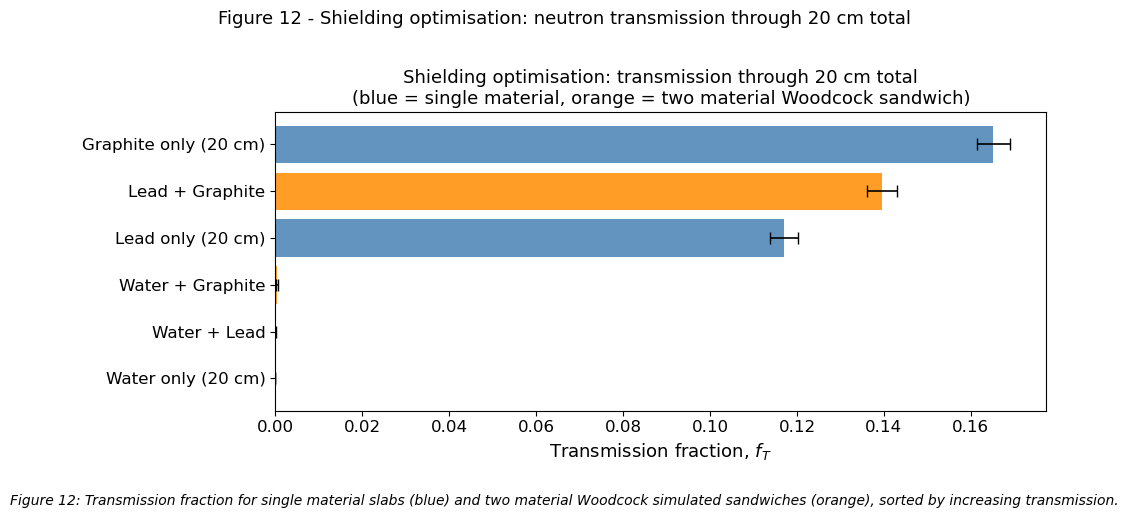

Configuration                   f_T (%)  sigma (%)
--------------------------------------------------
Water only (20 cm)                0.000      0.000
Water + Lead                      0.010      0.010
Water + Graphite                  0.050      0.022
Lead only (20 cm)                11.710      0.322
Lead + Graphite                  13.950      0.346
Graphite only (20 cm)            16.520      0.371


In [48]:
plt.close('all')

L_HALF = 10.0
mat_names = list(MATERIALS.keys())
combos = [('Water', 'Lead'), ('Water', 'Graphite'), ('Lead', 'Graphite')]

print('Running shielding optimisation simulations')
t_start = time.time()
shield_results = {}

# Baseline: 20 cm single material slabs:
for name in mat_names:
    shield_results[f'{name} only (20 cm)'] = run_simulation(
        2 * L_HALF, props[name], N=N_FIXED
    )

# Two material sandwiches via the Woodcock method:
for m1, m2 in combos:
    shield_results[f'{m1} + {m2}'] = run_woodcock_simulation(
        L_HALF, L_HALF, props[m1], props[m2], N=N_FIXED
    )

print(f'Shielding optimisation completed in {time.time() - t_start:.1f} s\n')

# Sort by ascending transmission and plot:
labels = list(shield_results.keys())
f_T_val = np.array([shield_results[l]['f_T'] for l in labels])
f_T_err = np.array([shield_results[l]['sigma_T'] for l in labels])
order = np.argsort(f_T_val)
labels_s = [labels[i] for i in order]
f_T_s = f_T_val[order]
f_T_err_s = f_T_err[order]
colours_bar = ['steelblue' if 'only' in l else 'darkorange' for l in labels_s]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(labels_s)), f_T_s, xerr=f_T_err_s,
        color=colours_bar, alpha=0.85, capsize=4, ecolor='black',
        error_kw={'elinewidth': 1.2})
ax.set_yticks(range(len(labels_s)))
ax.set_yticklabels(labels_s)
ax.set_xlabel('Transmission fraction, $f_T$')
ax.set_title('Shielding optimisation: transmission through 20 cm total\n'
             '(blue = single material, orange = two material Woodcock sandwich)')
plt.suptitle('Figure 12 - Shielding optimisation: neutron transmission through 20 cm total',
             fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 12: Transmission fraction for single material slabs (blue) and '
         'two material Woodcock simulated sandwiches (orange), sorted by increasing transmission.',
         ha='center', fontsize=10, style='italic')
plt.show()

print(f"{'Configuration':<28} {'f_T (%)':>10} {'sigma (%)':>10}")
print('-' * 50)
for l, f, s in zip(labels_s, f_T_s, f_T_err_s):
    print(f'{l:<28} {f*100:>10.3f} {s*100:>10.3f}')


### 11.1 Discussion of Shielding Optimisation

The primary finding is that water alone outperforms any combination involving water plus another material at the same total thickness, because water attenuates so strongly within 10 cm that the second layer adds essentially no further suppression and most neutrons are already removed before reaching it. This illustrates a general principle of shielding: when one material has a far shorter mean free path than another, adding the weaker material is wasteful unless it provides some complementary benefit (e.g. gamma absorption by lead, which is not captured by this single group thermal approximation).

Among combinations not involving water, the lead–graphite sandwich outperforms graphite alone because lead provides the absorption that graphite lacks. This complementarity is the main motivation for layered shielding in real reactor designs. This analysis treats only neutron transport in a thermal energy, single group approximation. Real shielding design must additionally account for gamma rays, fast neutrons, structural constraints, and weight.


---
## Section 12 - Woodcock Method for Adjacent Material Slabs

### 12.1 Theory

The Woodcock method (also known as fictitious tracking or delta tracking) handles material boundaries without requiring explicit geometric calculations to identify when a step crosses an interface [2]. The key idea is to define a majorant cross-section $\Sigma_T^{\rm maj} = \max(\Sigma_{T,1}, \Sigma_{T,2})$ and draw all step lengths from the fixed exponential distribution with mean $\lambda_{\min} = 1/\Sigma_T^{\rm maj}$.

Because the majorant over estimates the true cross-section wherever $\Sigma_T^{\rm true} < \Sigma_T^{\rm maj}$, at each step endpoint the interaction is classified as real (probability $\Sigma_T^{\rm true}/\Sigma_T^{\rm maj}$) or **fictitious** (probability $1 - \Sigma_T^{\rm true}/\Sigma_T^{\rm maj}$). Real interactions absorb or scatter using the local branching ratio, fictitious interactions are no-ops (no physical effect). The advantage is that boundary crossings require no special handling: the only quantity that changes at a boundary is which $\Sigma_T^{\rm true}$ is looked up. The functions implementing this algorithm were defined in Section 11.


### 12.2 Validation: Same Material Self-Consistency Check

An essential validation of the Woodcock implementation is the same material consistency check. When both slabs are configured as the same material, the Woodcock method must reproduce the result of a standard 20 cm single material simulation to within Monte Carlo statistical error. When both materials are identical, $\Sigma_{\rm local} = \Sigma_{\rm max}$ everywhere, so all interactions are real and fictitious tracking reduces exactly to standard tracking.


In [49]:
print(' Woodcock Validation - Same Material Self-Consistency')
print(' ')

for name in MATERIALS:
    # Woodcock: two 10 cm slabs of the same material (total 20 cm).
    wc_res = run_woodcock_simulation(10, 10, props[name], props[name], N=N_FIXED)
    # Standard: one 20 cm slab of the same material.
    std_res = run_simulation(20, props[name], N=N_FIXED)

    # Combined uncertainty on the difference between two independent estimates.
    combined_sigma = np.sqrt(wc_res['sigma_T']**2 + std_res['sigma_T']**2)
    delta = abs(wc_res['f_T'] - std_res['f_T'])

    if combined_sigma == 0:
        verdict = 'PASS (both zero, consistent)'
        diff_str = 'N/A'
    else:
        diff_sigma = delta / combined_sigma
        verdict = 'PASS' if diff_sigma < 3 else 'FAIL'
        diff_str = f'{diff_sigma:.2f} sigma'

    print(f'\n{name} | {name} (10 cm + 10 cm) vs. {name} (20 cm):')
    print(f' Woodcock f_T = {wc_res["f_T"]*100:6.3f} +/- {wc_res["sigma_T"]*100:.3f} %')
    print(f' Standard f_T = {std_res["f_T"]*100:6.3f} +/- {std_res["sigma_T"]*100:.3f} %')
    print(f' Discrepancy : {diff_str}  ->  {verdict}')


 Woodcock Validation - Same Material Self-Consistency
 

Water | Water (10 cm + 10 cm) vs. Water (20 cm):
 Woodcock f_T =  0.020 +/- 0.014 %
 Standard f_T =  0.010 +/- 0.010 %
 Discrepancy : 0.58 sigma  ->  PASS

Lead | Lead (10 cm + 10 cm) vs. Lead (20 cm):
 Woodcock f_T = 11.620 +/- 0.320 %
 Standard f_T = 11.820 +/- 0.323 %
 Discrepancy : 0.44 sigma  ->  PASS

Graphite | Graphite (10 cm + 10 cm) vs. Graphite (20 cm):
 Woodcock f_T = 17.510 +/- 0.380 %
 Standard f_T = 17.270 +/- 0.378 %
 Discrepancy : 0.45 sigma  ->  PASS


### 12.3 Two-Material Results and the Material Ordering Effect

With the implementation validated, the Woodcock method is applied to all six **ordered** pairs of distinct materials, with each layer 10 cm thick. The motivation for testing both orderings (e.g., Water then Lead **and** Lead then Water) is physical: the order in which a neutron encounters materials can affect its overall fate. Placing a strongly-scattering material first randomises the neutron's direction before it encounters the second material, while placing the more-absorbing material first increases the chance of capture before any directional randomisation occurs.


Running Woodcock simulations for all ordered material pairs
Woodcock simulations completed in 23.6 s



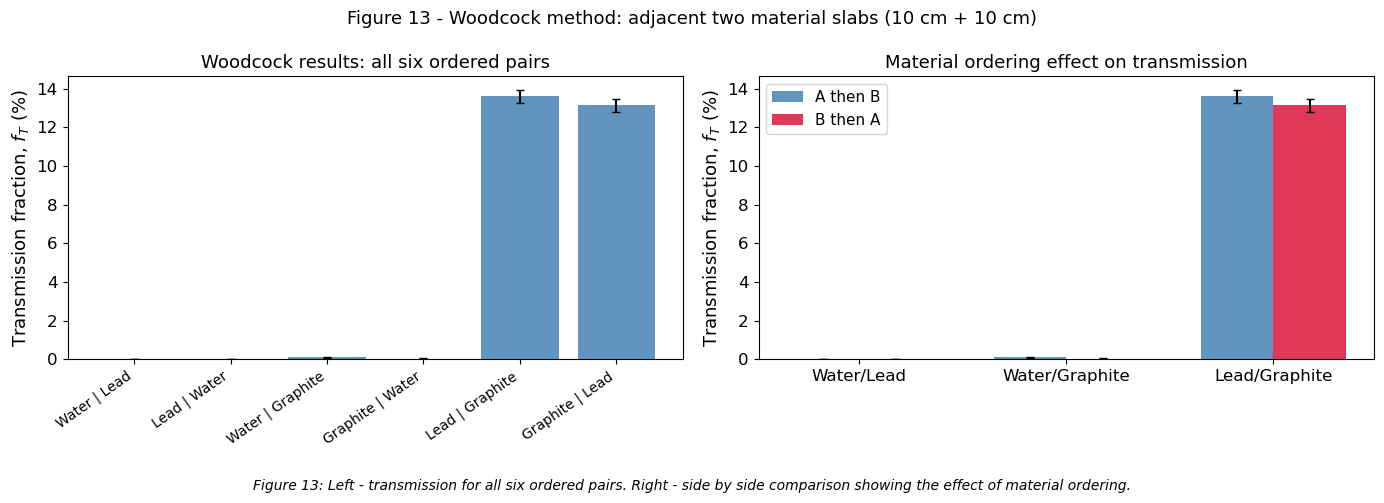

Pair                          f_T (%)        f_R (%)        f_A (%)
--------------------------------------------------------------------
Water | Lead                 0.02+/-0.01      79.76+/-0.40      20.22+/-0.40
Lead | Water                 0.02+/-0.01      88.92+/-0.31      11.06+/-0.31
Water | Graphite             0.11+/-0.03      79.63+/-0.40      20.26+/-0.40
Graphite | Water             0.04+/-0.02      94.96+/-0.22       5.00+/-0.22
Lead | Graphite             13.60+/-0.34      72.34+/-0.45      14.06+/-0.35
Graphite | Lead             13.14+/-0.34      79.69+/-0.40       7.17+/-0.26


In [50]:
plt.close('all')

# All six ordered pairings of distinct materials.
ordered_pairs = [
    ('Water', 'Lead'), ('Lead', 'Water'),
    ('Water', 'Graphite'), ('Graphite', 'Water'),
    ('Lead', 'Graphite'), ('Graphite', 'Lead'),
]

print('Running Woodcock simulations for all ordered material pairs')
t_start = time.time()
wc_results = {}
for m1, m2 in ordered_pairs:
    wc_results[f'{m1} | {m2}'] = run_woodcock_simulation(
        L_HALF, L_HALF, props[m1], props[m2], N=N_FIXED
    )
print(f'Woodcock simulations completed in {time.time() - t_start:.1f} s\n')

wc_labels = list(wc_results.keys())
wc_fT = np.array([wc_results[l]['f_T'] for l in wc_labels])
wc_sT = np.array([wc_results[l]['sigma_T'] for l in wc_labels])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(wc_labels))
axes[0].bar(x_pos, wc_fT * 100, yerr=wc_sT * 100,
            color='steelblue', alpha=0.85, capsize=3)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(wc_labels, rotation=35, ha='right', fontsize=10)
axes[0].set_ylabel('Transmission fraction, $f_T$ (%)')
axes[0].set_title('Woodcock results: all six ordered pairs')

# Side-by-side ordering comparison (A|B vs B|A).
pair_labels = ['Water/Lead', 'Water/Graphite', 'Lead/Graphite']
fw_ab = np.array([wc_results[f'{m1} | {m2}']['f_T'] * 100 for m1, m2 in ordered_pairs[0::2]])
fw_ba = np.array([wc_results[f'{m2} | {m1}']['f_T'] * 100 for m1, m2 in ordered_pairs[0::2]])
sw_ab = np.array([wc_results[f'{m1} | {m2}']['sigma_T'] * 100 for m1, m2 in ordered_pairs[0::2]])
sw_ba = np.array([wc_results[f'{m2} | {m1}']['sigma_T'] * 100 for m1, m2 in ordered_pairs[0::2]])

x2 = np.arange(len(pair_labels))
width = 0.35
axes[1].bar(x2 - width/2, fw_ab, width, yerr=sw_ab, label='A then B',
            color='steelblue', alpha=0.85, capsize=3)
axes[1].bar(x2 + width/2, fw_ba, width, yerr=sw_ba, label='B then A',
            color='crimson',   alpha=0.85, capsize=3)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(pair_labels)
axes[1].set_ylabel('Transmission fraction, $f_T$ (%)')
axes[1].set_title('Material ordering effect on transmission')
axes[1].legend()

plt.suptitle('Figure 13 - Woodcock method: adjacent two material slabs (10 cm + 10 cm)',
             fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         'Figure 13: Left - transmission for all six ordered pairs. '
         'Right - side by side comparison showing the effect of material ordering.',
         ha='center', fontsize=10, style='italic')
plt.show()

print(f"{'Pair':<22} {'f_T (%)':>14} {'f_R (%)':>14} {'f_A (%)':>14}")
print('-' * 68)
for label in wc_labels:
    r = wc_results[label]
    print(f"{label:<22} {r['f_T']*100:>10.2f}+/-{r['sigma_T']*100:.2f} "
          f"{r['f_R']*100:>10.2f}+/-{r['sigma_R']*100:.2f} "
          f"{r['f_A']*100:>10.2f}+/-{r['sigma_A']*100:.2f}")


### 12.4 Discussion of Woodcock Results

The Woodcock results yield several physically interesting observations. For any pair involving water, total transmission is small and largely independent of ordering - water attenuates so strongly within 10 cm that very few neutrons reach the second slab regardless of what follows. The most physically interesting case is the lead–graphite pair, where neither material overwhelms the other: transmission depends measurably on which layer the neutron encounters first, with the ordering that places the scattering dominant material first producing a slightly higher transmission (more neutrons are redirected sideways rather than absorbed before reaching the interface).

The same material validation tests in Section 12.2 confirm that the Woodcock implementation is internally consistent. All three materials pass the self consistency check within Monte Carlo statistical uncertainty, providing confidence that the fictitious tracking logic is correctly implemented and that the boundary handling introduces no systematic bias.


---
## Conclusions

A complete Monte Carlo simulation of thermal neutron transport through shielding materials has been made, implementing inverse transform sampling of the exponential free-path distribution, isotropic scattering with pole-free spherical sampling, and the Woodcock fictitious-tracking method for mixed-material geometries.

Of the three materials studied, water is the most effective shield per unit thickness, owing to its very large scattering cross-section (103 barn) which produces a sub-half-centimetre total mean free path and near-complete attenuation within 10 cm. Lead provides intermediate attenuation. Graphite, despite the smallest absorption cross-section by nearly two orders of magnitude, still attenuates a substantial fraction of incident neutrons via reflection, making it valuable as a moderator rather than a shield [5].

The fitted characteristic attenuation lengths $\Lambda$ are much shorter than the absorption-only mean free paths $\lambda_a$ for all three materials. This confirms that scattering induced reflection out of the entry face is the dominant loss mechanism for a finite slab when $\Sigma_s \gg \Sigma_a$, and that Beer-Lambert models are quantitatively inadequate whenever scattering is significant.

The convergence analysis confirmed the expected $1/\sqrt{N}$ for $N$ ranging from $100$ to $50000$. The shielding optimisation demonstrated that two material sandwiches do not generally outperform the strongest single material at the same total thickness. The Woodcock method was validated via same material self-consistency tests and applied to all six ordered material pairs, quantifying the material ordering effect and showing that the path through a layered shield, not just its composition, affects neutron transport outcomes.


---
## References

[1] G. Marsaglia, "Random numbers fall mainly in the planes," *Proceedings of the National Academy of Sciences*, vol. 61, no. 1, pp. 25–28, 1968.

[2] E. R. Woodcock, T. Murphy, P. J. Hemmings, and T. C. Longworth, "Techniques used in the GEM code for Monte Carlo neutronics calculations in reactors and other systems of complex geometry," in *Proc. Conf. Applications of Computing Methods to Reactor Problems*, Argonne National Laboratory, ANL-7050, 1965.

[3] W. H. Press, S. A. Teukolsky, W. T. Vetterling, and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed. Cambridge: Cambridge University Press, 2007, ch. 7 (Random Numbers).

[4] National Institute of Standards and Technology, "Neutron scattering lengths and cross sections," NIST Center for Neutron Research. [Online]. Available: https://www.ncnr.nist.gov/resources/n-lengths/ [Accessed: May 2026].

[5] J. R. Lamarsh and A. J. Baratta, *Introduction to Nuclear Engineering*, 3rd ed. Upper Saddle River, NJ: Pearson, 2001, ch. 4.
